# ADEF v3.2

**Adaptive Evidential Fusion with Learned Soft Conflict Gating & Deep Gated Co-Attention**

v2 → v3 improvements:
1. **Soft-learnable conflict gate** — differentiable σ((K−τ)/s), replaces hard τ-mask
2. **Deep gated co-attention** — 2 stacked layers with tanh-gated residual updates
3. **Vacuous-opinion dropout** — train-time modality dropout via DST vacuous beliefs (b=0,u=1)
4. **Jøsang uncertainty discounting** — learned per-branch reliability scalars
5. **Digamma evidential loss** — expected cross-entropy (less overconfidence than SoS)
6. **Label smoothing 0.05 + sqrt-class-weights + GAMMA=0.1**
7. **Early stopping** (patience 6) + **3-seed** evaluation (mean±std)


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import torchvision.transforms as transforms
import torchvision.models as models
from transformers import RobertaTokenizer, RobertaModel

from PIL import Image
import pandas as pd
import numpy as np
import os
import warnings
import random
import copy
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

# ============================================================
# REPRODUCIBILITY
# ============================================================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)
print("✅ Imports loaded & seed set.")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")


C:\Users\Residensi ADW\AppData\Roaming\Python\Python310\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Imports loaded & seed set.
PyTorch version: 2.5.1
CUDA available: True
GPU: NVIDIA GeForce RTX 3060


In [2]:
# ============================================================
# CONFIGURATION v3.2 (single source of truth for ALL hyperparameters)
# ============================================================

class CFG:
    # =========================
    # PATH
    # =========================
    ROOT_DIR = r"D:/MVSA_SINGLE"
    DATA_DIR = r"D:/MVSA_SINGLE/data"
    LABEL_PATH = r"D:/MVSA_SINGLE/labelResultAllFinal.txt"

    # =========================
    # DEVICE
    # =========================
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

    # =========================
    # DATA
    # =========================
    FILTER_CONFLICT_PAIRS = True     # True = baseline-compatible; False = ablation (real conflict)
    NEUTRAL_OVERSAMPLE = 1           # v3.2: neutral oversampling factor (1 = off, 2 = 2x neutral)

    # =========================
    # OPTIMIZATION HYPERPARAMETERS
    # =========================
    BATCH_SIZE = 16
    EPOCHS = 30
    LR = 1e-4
    WEIGHT_DECAY = 1e-3
    GRAD_CLIP = 1.0
    SCHED_TMAX = 30
    DROPOUT = 0.5
    SEED = 42
    SEEDS = [42, 1337, 2024]         # 3-seed evaluation

    # =========================
    # EARLY STOPPING
    # =========================
    EARLY_STOP_PATIENCE = 6

    # =========================
    # CHECKPOINT SAVING
    # =========================
    CHECKPOINT_DIR = "checkpoints"

    # =========================
    # ARCHITECTURE HYPERPARAMETERS
    # =========================
    MAX_LEN = 150
    D_BERT = 768
    D_CNN = 1024
    D_PROJ = 512
    NUM_CLASSES = 3
    COATTN_LAYERS = 2                # stacked gated co-attention

    # =========================
    # EDL / ADEF HYPERPARAMETERS
    # =========================
    ANNEALING_EPOCHS = 10
    EDL_LOSS_TYPE = "digamma"        # "digamma" (expected-CE) | "sos" (Bayes risk) | "both"
    LABEL_SMOOTHING = 0.0
    TAU = 0.036                      # init gate tau center
    GATE_TYPE = "parametric"         # "parametric" (sigma((K-tau)/s)) | "mlp"
    GATE_LEARNABLE = True
    GATE_TEMP_INIT = 0.02            # initial temperature for sigmoid gate
    OPINION_DROP_PROB = 0.15         # vacuous-opinion dropout prob (train only)
    USE_DISCOUNTING = True           # Josang pre-fusion discounting
    GAMMA = 0.1                      # L_con weight
    LAMBDA_FUSED = 1.0
    USE_CLASS_WEIGHTS = True
    CLASS_WEIGHT_MODE = "inv"        # "inv" (full inverse-freq) | "sqrt_inv" (softens with oversampling)
    U_MIN = 0.05

    # =========================
    # MODEL SELECTION / EVALUATION
    # =========================
    SELECT_METRIC = "macro_f1"
    UCE_BINS = 10

    # =========================
    # PRETRAINED MODELS
    # =========================
    TEXT_MODEL = "roberta-base"
    IMAGE_MODEL = "densenet121"

print(f"\u2705 CFG v3.2 loaded. Device: {CFG.DEVICE}  |  Gate: {CFG.GATE_TYPE}  |  Loss: {CFG.EDL_LOSS_TYPE}")
print(f"   CoAttn layers={CFG.COATTN_LAYERS}  Drop={CFG.OPINION_DROP_PROB}  Discount={CFG.USE_DISCOUNTING}  Gamma={CFG.GAMMA}")
print(f"   Smoothing={CFG.LABEL_SMOOTHING}  Class weights={CFG.CLASS_WEIGHT_MODE}  Dropout={CFG.DROPOUT}")
print(f"   Neutral oversampling={CFG.NEUTRAL_OVERSAMPLE}x  Checkpoints: {CFG.CHECKPOINT_DIR}")


✅ CFG v3.1 loaded. Device: cuda  |  Gate: parametric  |  Loss: digamma
   CoAttn layers=2  Drop=0.15  Discount=True  Gamma=0.1
   Smoothing=0.0  Class weights=inv  Dropout=0.5
   Checkpoints: checkpoints


In [3]:
import pandas as pd
import os
# ============================================================
# LOAD DATASET
# ============================================================

df = pd.read_csv(CFG.LABEL_PATH, header=0, sep=",")
df.columns = ["id", "text_label", "image_label", "final_label"]

# Filter contradictory text-image pairs (text+ / image- and vice versa).
# NOTE: these ARE the cross-modal conflict cases ADEF Route B was designed for.
# Default True keeps the dataset identical to the 4 baseline notebooks
# (fair comparison). Set CFG.FILTER_CONFLICT_PAIRS = False for ablation.
def is_valid(row):

    if row["text_label"] == "positive" and row["image_label"] == "negative":
        return False

    if row["text_label"] == "negative" and row["image_label"] == "positive":
        return False

    return True

if CFG.FILTER_CONFLICT_PAIRS:
    df = df[df.apply(is_valid, axis=1)]
    df = df.reset_index(drop=True)

print(f"Dataset size after filtering: {len(df)}  (FILTER_CONFLICT_PAIRS={CFG.FILTER_CONFLICT_PAIRS})")

label_map = {
    "negative": 0,
    "neutral": 1,
    "positive": 2
}

id2label = {
    0: "negative",
    1: "neutral",
    2: "positive"
}

df["label"] = df["final_label"].map(label_map)

# Load text file dengan better error handling
def load_text(sample_id):
    path = os.path.join(CFG.DATA_DIR, f"{sample_id}.txt")

    encodings = ["utf-8", "latin-1", "cp1252", "iso-8859-1"]

    for encoding in encodings:
        try:
            with open(path, "r", encoding=encoding) as f:
                text = f.read().strip()
                if text:  # Jika text berhasil dibaca dan tidak kosong
                    return text
        except FileNotFoundError:
            continue
        except Exception as e:
            continue

    # Jika semua encoding gagal atau file tidak ada
    return ""

df["text"] = df["id"].apply(load_text)

# Hitung empty text
empty_text_count = (df["text"] == "").sum()
print(f"\n{'='*60}")
print(f"PREPROCESSING STATISTICS:")
print(f"{'='*60}")
print(f"Total samples: {len(df)}")
print(f"Samples with EMPTY text: {empty_text_count}")
print(f"Samples with VALID text: {len(df) - empty_text_count}")
print(f"Percentage of empty text: {(empty_text_count/len(df)*100):.2f}%")
print(f"{'='*60}\n")

# image path
df["image_path"] = df["id"].apply(
    lambda x: os.path.join(CFG.DATA_DIR, f"{x}.jpg")
)

df.head()

Dataset size after filtering: 4511  (FILTER_CONFLICT_PAIRS=True)

PREPROCESSING STATISTICS:
Total samples: 4511
Samples with EMPTY text: 0
Samples with VALID text: 4511
Percentage of empty text: 0.00%



,id,text_label,image_label,final_label,label,text,image_path
0,1,neutral,positive,positive,2,How I feel today #legday #jelly #aching #gym,D:/MVSA_SINGLE/data\1.jpg
1,2,neutral,positive,positive,2,grattis min griskulting!!!???? va bara tvungen...,D:/MVSA_SINGLE/data\2.jpg
2,3,neutral,positive,positive,2,RT @polynminion: The moment I found my favouri...,D:/MVSA_SINGLE/data\3.jpg
3,4,positive,positive,positive,2,#escort We have a young and energetic team and...,D:/MVSA_SINGLE/data\4.jpg
4,5,positive,positive,positive,2,"RT @chrisashaffer: Went to SSC today to be a ""...",D:/MVSA_SINGLE/data\5.jpg


In [4]:
# ============================================================
# PYTORCH DATASET & DATALOADERS
# ============================================================

# MVSADataset: PyTorch Dataset for MVSA multimodal sentiment analysis.
class MVSADataset(Dataset):

    def __init__(self, dataframe, tokenizer, transform, max_len=150):
        self.df = dataframe.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.transform = transform
        self.max_len = max_len

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        text = str(row["text"]) if pd.notna(row["text"]) else ""
        image_path = row["image_path"]
        label = int(row["label"])

        # Tokenize text
        encoding = self.tokenizer(
            text,
            max_length=self.max_len,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )
        input_ids = encoding["input_ids"].squeeze(0)
        attention_mask = encoding["attention_mask"].squeeze(0)

        # Load and transform image
        try:
            image = Image.open(image_path).convert("RGB")
            image = self.transform(image)
        except Exception:
            image = torch.zeros(3, 224, 224)

        return {
            "input_ids": input_ids,
            "attention_mask": attention_mask,
            "image": image,
            "label": torch.tensor(label, dtype=torch.long)
        }


# ============================================================
# INITIALIZE TOKENIZER & TRANSFORMS
# ============================================================
tokenizer = RobertaTokenizer.from_pretrained(CFG.TEXT_MODEL)

image_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# ============================================================
# STRATIFIED SPLIT: 70% train, 15% val, 15% test
# ============================================================
train_df, temp_df = train_test_split(
    df, test_size=0.3, stratify=df["label"], random_state=CFG.SEED
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, stratify=temp_df["label"], random_state=CFG.SEED
)

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
print(f"\nTrain label distribution:")
print(train_df['label'].value_counts().sort_index())
print(f"\nVal label distribution:")
print(val_df['label'].value_counts().sort_index())
print(f"\nTest label distribution:")
print(test_df['label'].value_counts().sort_index())

# Create datasets
train_dataset = MVSADataset(train_df, tokenizer, image_transform, CFG.MAX_LEN)
val_dataset = MVSADataset(val_df, tokenizer, image_transform, CFG.MAX_LEN)
test_dataset = MVSADataset(test_df, tokenizer, image_transform, CFG.MAX_LEN)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=CFG.BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=CFG.BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=CFG.BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

print(f"\n\u2705 DataLoaders created.")
print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)} | Test batches: {len(test_loader)}")


Train: 3157 | Val: 677 | Test: 677

Train label distribution:
label
0     950
1     329
2    1878
Name: count, dtype: int64

Val label distribution:
label
0    204
1     71
2    402
Name: count, dtype: int64

Test label distribution:
label
0    204
1     70
2    403
Name: count, dtype: int64

✅ DataLoaders created.
Train batches: 198 | Val batches: 43 | Test batches: 43


In [5]:
# ============================================================
# FEATURE EXTRACTORS (Sequence-Level for Co-Attention)
# ============================================================

# RoBERTa text encoder -> token-level features + masked mean-pooled vector.
# v1 pooled to a single vector BEFORE attention, degenerating the attention
# matrix to a scalar. v2 keeps token-level features for fine-grained alignment.
# Input:  input_ids [B, L_t], attention_mask [B, L_t]
# Output: H_t  [B, L_t, d_proj] (token features for co-attention)
#         h_t  [B, d_proj]      (pooled vector for unimodal ENN head)
#         attention_mask [B, L_t]
class TextEncoder(nn.Module):

    def __init__(self, d_bert=768, d_proj=512):
        super().__init__()
        self.roberta = RobertaModel.from_pretrained(CFG.TEXT_MODEL)
        # Freeze RoBERTa parameters (fair comparison with baseline notebooks)
        for param in self.roberta.parameters():
            param.requires_grad = False

        self.projection = nn.Sequential(
            nn.Linear(d_bert, d_proj),
            nn.ReLU(),
            nn.LayerNorm(d_proj)
        )

    def forward(self, input_ids, attention_mask):
        with torch.no_grad():
            outputs = self.roberta(input_ids=input_ids, attention_mask=attention_mask)
        H_t = self.projection(outputs.last_hidden_state)  # [B, L_t, d_proj]

        # Masked mean-pooling -> pooled text vector
        mask = attention_mask.unsqueeze(-1).float()       # [B, L_t, 1]
        h_t = (H_t * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1e-10)  # [B, d_proj]
        return H_t, h_t, attention_mask


# DenseNet-121 image encoder -> spatial (patch) features + pooled vector.
# Input:  image [B, 3, 224, 224]
# Output: H_v [B, N_v, d_proj] (N_v = 49 patch features for co-attention)
#         h_v [B, d_proj]      (pooled vector for unimodal ENN head)
class ImageEncoder(nn.Module):

    def __init__(self, d_cnn=1024, d_proj=512):
        super().__init__()
        densenet = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)
        self.features = densenet.features
        # Freeze DenseNet parameters
        for param in self.features.parameters():
            param.requires_grad = False

        self.projection = nn.Sequential(
            nn.Linear(d_cnn, d_proj),
            nn.ReLU(),
            nn.LayerNorm(d_proj)
        )

    def forward(self, x):
        with torch.no_grad():
            features = self.features(x)  # [B, 1024, 7, 7]
        B, C, H, W = features.shape

        # Spatial features: [B, N_v, 1024] -> project
        H_v = features.view(B, C, H * W).permute(0, 2, 1)  # [B, N_v, 1024]
        H_v = self.projection(H_v)                          # [B, N_v, d_proj]
        h_v = H_v.mean(dim=1)                               # [B, d_proj]
        return H_v, h_v


print("\u2705 TextEncoder (sequence) & ImageEncoder (spatial) defined.")

✅ TextEncoder (sequence) & ImageEncoder (spatial) defined.


In [6]:
# ============================================================
# DEEP GATED BI-COATTENTION (v3)
# ============================================================
# Stacks N layers of simultaneous gated bidirectional co-attention.
# Each layer applies text->visual AND visual->text attention in parallel
# using the SAME input features, then updates both modalities via
# tanh-gated residual connections.
#
# Layer l:
#   S   = H_t @ W_l @ H_v^T / sqrt(d)           -- affinity [B, L_t, N_v]
#   v2t = softmax(S, dim=patches) @ H_v          -- text-attended visual features
#   t2v = softmax(S^T, dim=tokens, masked) @ H_t -- visual-attended text features
#   H_t <- H_t + tanh(Linear_t(H_t)) * v2t       -- gated residual (text)
#   H_v <- H_v + tanh(Linear_v(H_v)) * t2v       -- gated residual (visual)
#
# Final h_c: concat(masked-mean(H_t_final), mean(H_v_final)) -> MLP -> [d]
# The gating allows the model to learn HOW MUCH cross-modal information
# to absorb at each layer, preventing co-adaptation overfitting.


class GatedBiCoAttention(nn.Module):
    def __init__(self, d_proj=512, dropout=0.45, num_layers=2):
        super().__init__()
        self.d_proj = d_proj
        self.num_layers = num_layers

        for layer_idx in range(num_layers):
            setattr(self, f"W_attn_{layer_idx}", nn.Linear(d_proj, d_proj, bias=False))
            setattr(self, f"gate_t_{layer_idx}", nn.Linear(d_proj, d_proj))
            setattr(self, f"gate_v_{layer_idx}", nn.Linear(d_proj, d_proj))

        self.fusion_proj = nn.Sequential(
            nn.Linear(2 * d_proj, d_proj),
            nn.ReLU(),
            nn.LayerNorm(d_proj),
            nn.Dropout(dropout)
        )

    def forward(self, H_t, H_v, text_mask):
        # H_t: [B, L_t, d_proj]   H_v: [B, N_v, d_proj]   text_mask: [B, L_t]
        pad_mask = (text_mask == 0).unsqueeze(1)  # [B, 1, L_t]

        for layer_idx in range(self.num_layers):
            W = getattr(self, f"W_attn_{layer_idx}")
            gate_t = getattr(self, f"gate_t_{layer_idx}")
            gate_v = getattr(self, f"gate_v_{layer_idx}")

            # Affinity matrix
            S = torch.bmm(W(H_t), H_v.transpose(1, 2)) / (self.d_proj ** 0.5)  # [B, L_t, N_v]

            # Text -> Visual (each token attends over all patches)
            A_tv = F.softmax(S, dim=-1)                # [B, L_t, N_v]
            v2t = torch.bmm(A_tv, H_v)                  # [B, L_t, d]

            # Visual -> Text (each patch attends over non-pad tokens)
            S_T = S.transpose(1, 2).masked_fill(pad_mask, -1e9)  # [B, N_v, L_t]
            A_vt = F.softmax(S_T, dim=-1)              # [B, N_v, L_t]
            t2v = torch.bmm(A_vt, H_t)                  # [B, N_v, d]

            # Gated residual (SIMULTANEOUS: both use input H_t, H_v, not updated mid-layer)
            H_t = H_t + torch.tanh(gate_t(H_t)) * v2t
            H_v = H_v + torch.tanh(gate_v(H_v)) * t2v

        # Pooling: masked-mean for text, mean for visual
        mask = text_mask.unsqueeze(-1).float()
        t_summary = (H_t * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1e-10)
        v_summary = H_v.mean(dim=1)
        h_c = self.fusion_proj(torch.cat([t_summary, v_summary], dim=1))
        return h_c


print("\u2705 GatedBiCoAttention (v3, {CFG.COATTN_LAYERS}-layer) defined.".format(CFG=CFG))


✅ GatedBiCoAttention (v3, 2-layer) defined.


In [7]:
# ============================================================
# ENN HEAD & SUBJECTIVE LOGIC UTILITIES
# ============================================================

class ENNHead(nn.Module):
    def __init__(self, d_proj=512, num_classes=3, dropout=0.45):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(d_proj, d_proj // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_proj // 2, num_classes),
            nn.Softplus()
        )

    def forward(self, h):
        evidence = self.fc(h)
        alpha = evidence + 1
        return alpha


def compute_belief_uncertainty(alpha, num_classes=3, eps=1e-8):
    S = torch.sum(alpha, dim=1, keepdim=True)
    e = alpha - 1
    b = e / (S + eps)
    u = num_classes / (S + eps)
    return b, u, S


# ============================================================
# JOSANG'S DISCOUNTING OPERATOR (v3)
# ============================================================
# Applies pre-fusion reliability discounting per branch.
#   b' = r * b
#   u' = 1 - r * (1 - u)  =  r*u + (1-r)
# r = 1: identity (fully trust the branch)
# r -> 0: vacuous opinion (b=0, u=1) -- "I don't know"
# Learned scalar r = sigmoid(raw_r), initialized to ~0.9


class ReliabilityDiscounter(nn.Module):
    def __init__(self, name="t"):
        super().__init__()
        self.name = name
        self.raw_r = nn.Parameter(torch.tensor(2.197, dtype=torch.float32))  # sigmoid(2.197) ~ 0.9

    def forward(self, b, u):
        r = torch.sigmoid(self.raw_r)
        b_discounted = r * b
        u_discounted = r * u + (1.0 - r)
        return b_discounted, u_discounted


print("\u2705 ENNHead, Subjective Logic utils & ReliabilityDiscounter defined.")


✅ ENNHead, Subjective Logic utils & ReliabilityDiscounter defined.


In [8]:
# ============================================================
# SOFT CONFLICT GATE (v3 -- differentiable, learnable)
# ============================================================
# Replaces the hard route_a_mask with a smooth sigmoid gate:
#   parametric:  g = sigma((K_tv - tau) / s),  tau in [0.01, 0.5], s > 0
#   mlp:         g = MLP([K_tv, u_t, u_v, u_c, L1(p_t, p_v)]) -> [0,1]
#
# Final fusion = (1 - g) * DS_fused  +  g * conflict_resolved
# Both routes ALWAYS contribute via soft blending; gradients flow through g
# back into the ENN heads via K_tv. This makes "Adaptive" truly LEARNED.


class SoftConflictGate(nn.Module):
    def __init__(self, gate_type="parametric", init_tau=0.036, init_temp=0.02):
        super().__init__()
        self.gate_type = gate_type

        if gate_type == "parametric":
            # tau = 0.01 + 0.49 * sigmoid(theta_tau)  ->  tau in [0.01, 0.5]
            tau_raw_val = np.log(init_tau / (0.5 - init_tau)) if init_tau < 0.5 else 5.0
            self.theta_tau = nn.Parameter(torch.tensor(tau_raw_val, dtype=torch.float32))
            # s = softplus(theta_temp) + 1e-4  ->  s > 0
            temp_raw_val = np.log(init_temp)
            self.theta_temp = nn.Parameter(torch.tensor(temp_raw_val, dtype=torch.float32))

        elif gate_type == "mlp":
            self.gate_net = nn.Sequential(
                nn.Linear(5, 16),
                nn.ReLU(),
                nn.Linear(16, 1),
                nn.Sigmoid()
            )
        else:
            raise ValueError(f"Unknown gate_type: {gate_type}")

    def forward(self, K_tv, u_t, u_v, u_c, p_t, p_v):
        if self.gate_type == "parametric":
            tau = 0.01 + 0.49 * torch.sigmoid(self.theta_tau)
            s = F.softplus(self.theta_temp) + 1e-4
            g = torch.sigmoid((K_tv - tau) / s)
        else:  # mlp
            features = torch.cat([
                K_tv,
                u_t, u_v, u_c,
                torch.abs(p_t - p_v).mean(dim=1, keepdim=True)
            ], dim=1)
            g = self.gate_net(features)
        return g   # [B, 1], g ~ 1 = conflict, g ~ 0 = agree


# ============================================================
# ADEF v3 MODULE (soft routing + discounting + Dempster)
# ============================================================

class ADEFModuleV3(nn.Module):
    def __init__(self, num_classes=3, gate_type="parametric", init_tau=0.036,
                 init_temp=0.02, use_discounting=True):
        super().__init__()
        self.num_classes = num_classes
        self.use_discounting = use_discounting

        self.gate = SoftConflictGate(gate_type=gate_type, init_tau=init_tau,
                                     init_temp=init_temp)

        if use_discounting:
            self.discounter_t = ReliabilityDiscounter(name="t")
            self.discounter_v = ReliabilityDiscounter(name="v")
            self.discounter_c = ReliabilityDiscounter(name="c")

    def dempster_combine(self, b1, u1, b2, u2):
        eps = 1e-8
        b1_sum = torch.sum(b1, dim=1, keepdim=True)
        b2_sum = torch.sum(b2, dim=1, keepdim=True)
        C = b1_sum * b2_sum - torch.sum(b1 * b2, dim=1, keepdim=True)
        norm = 1.0 / torch.clamp(1.0 - C, min=eps)
        b_fused = norm * (b1 * b2 + b1 * u2 + b2 * u1)
        u_fused = norm * (u1 * u2)
        return b_fused, u_fused, C

    def forward(self, b_t, u_t, b_v, u_v, b_c, u_c):
        eps = 1e-8
        K = self.num_classes

        # --- 1. Discount opinions before fusion ---
        if self.use_discounting:
            b_t_d, u_t_d = self.discounter_t(b_t, u_t)
            b_v_d, u_v_d = self.discounter_v(b_v, u_v)
            b_c_d, u_c_d = self.discounter_c(b_c, u_c)
        else:
            b_t_d, u_t_d = b_t, u_t
            b_v_d, u_v_d = b_v, u_v
            b_c_d, u_c_d = b_c, u_c

        # --- 2. Class probabilities & conflict K_tv for gate ---
        p_t = b_t_d + u_t_d / K
        p_v = b_v_d + u_v_d / K

        b_t_sum_d = torch.sum(b_t_d, dim=1, keepdim=True)
        b_v_sum_d = torch.sum(b_v_d, dim=1, keepdim=True)
        K_tv = b_t_sum_d * b_v_sum_d - torch.sum(b_t_d * b_v_d, dim=1, keepdim=True)

        # --- 3. Soft conflict gate ---
        g = self.gate(K_tv, u_t_d, u_v_d, u_c_d, p_t, p_v)  # [B, 1]

        # --- 4. Route A: standard 2-stage Dempster fusion ---
        b_tv_a, u_tv_a, _ = self.dempster_combine(b_t_d, u_t_d, b_v_d, u_v_d)
        b_final_a, u_final_a, _ = self.dempster_combine(b_tv_a, u_tv_a, b_c_d, u_c_d)

        # --- 5. Route B: conflict-aware blending ---
        b_avg = (b_t_d + b_v_d) / 2.0
        b_final_b = (1.0 - K_tv) * b_avg + K_tv * b_c_d
        u_final_b = torch.clamp(1.0 - torch.sum(b_final_b, dim=1, keepdim=True), min=eps)

        # --- 6. Soft blend: final = (1-g) * RouteA + g * RouteB ---
        b_fusion = (1.0 - g) * b_final_a + g * b_final_b
        u_fusion = torch.clamp((1.0 - g) * u_final_a + g * u_final_b, min=eps, max=1.0)

        # --- 7. Final decision ---
        p_final = b_fusion + u_fusion / K

        return p_final, b_fusion, u_fusion, K_tv, g


print("\u2705 ADEFModuleV3 with soft conflict gate defined.")


✅ ADEFModuleV3 with soft conflict gate defined.


In [9]:
# ============================================================
# ADEFCoAttnNet v3
# ============================================================
# Changes from v2:
#   - GatedBiCoAttention (deep gated co-attention instead of 1-layer)
#   - Soft-learned conflict gate (differentiable routing)
#   - Vacuous-opinion dropout at train time (modality dropout via DST)
#   - Josang reliability discounting before fusion


class ADEFCoAttnNetV3(nn.Module):
    def __init__(self, d_proj=512, num_classes=3, dropout=0.45,
                 coattn_layers=2, gate_type="parametric", init_tau=0.036,
                 init_temp=0.02, use_discounting=True, opinion_drop_prob=0.0):
        super().__init__()
        # Feature extractors (sequence-level)
        self.text_encoder = TextEncoder(d_bert=CFG.D_BERT, d_proj=d_proj)
        self.image_encoder = ImageEncoder(d_cnn=CFG.D_CNN, d_proj=d_proj)

        # Deep gated co-attention
        self.co_attention = GatedBiCoAttention(
            d_proj=d_proj, dropout=dropout, num_layers=coattn_layers
        )

        # 3 independent ENN heads
        self.enn_text = ENNHead(d_proj=d_proj, num_classes=num_classes, dropout=dropout)
        self.enn_image = ENNHead(d_proj=d_proj, num_classes=num_classes, dropout=dropout)
        self.enn_coattn = ENNHead(d_proj=d_proj, num_classes=num_classes, dropout=dropout)

        # ADEF v3 fusion module (soft gate + discounting)
        self.adef = ADEFModuleV3(
            num_classes=num_classes, gate_type=gate_type, init_tau=init_tau,
            init_temp=init_temp, use_discounting=use_discounting
        )

        self.num_classes = num_classes
        self.opinion_drop_prob = opinion_drop_prob

    def forward(self, input_ids, attention_mask, image):
        # 1. Feature extraction (sequence-level + pooled)
        H_t, h_t, text_mask = self.text_encoder(input_ids, attention_mask)
        H_v, h_v = self.image_encoder(image)

        # 2. Deep gated co-attention
        h_c = self.co_attention(H_t, H_v, text_mask)

        # 3. ENN Heads -> Dirichlet parameters
        alpha_t = self.enn_text(h_t)
        alpha_v = self.enn_image(h_v)
        alpha_c = self.enn_coattn(h_c)

        # 4. Subjective Logic: belief & uncertainty
        b_t, u_t, _ = compute_belief_uncertainty(alpha_t, self.num_classes)
        b_v, u_v, _ = compute_belief_uncertainty(alpha_v, self.num_classes)
        b_c, u_c, _ = compute_belief_uncertainty(alpha_c, self.num_classes)

        # 5. Vacuous-opinion dropout (train only)
        #    Replace each unimodal opinion with vacuous (b=0, u=1) with prob p.
        #    DST identity: Dempster(vacuous, omega) = omega.
        #    This trains the fusion to handle missing/unreliable modalities
        #    and directly regularizes co-adaptation overfitting.
        if self.training and self.opinion_drop_prob > 0.0:
            B = b_t.shape[0]
            dev = b_t.device
            keep_t = (torch.rand(B, 1, device=dev) > self.opinion_drop_prob).float()
            keep_v = (torch.rand(B, 1, device=dev) > self.opinion_drop_prob).float()
            b_t = b_t * keep_t
            u_t = u_t * keep_t + (1.0 - keep_t)
            b_v = b_v * keep_v
            u_v = u_v * keep_v + (1.0 - keep_v)

        # 6. ADEF fusion (soft gate + discounting)
        p_final, b_fusion, u_fusion, K_tv, gate = self.adef(
            b_t, u_t, b_v, u_v, b_c, u_c
        )

        return {
            "alpha_t": alpha_t, "alpha_v": alpha_v, "alpha_c": alpha_c,
            "b_t": b_t, "u_t": u_t,
            "b_v": b_v, "u_v": u_v,
            "b_c": b_c, "u_c": u_c,
            "p_final": p_final,
            "b_fusion": b_fusion, "u_fusion": u_fusion,
            "K_tv": K_tv,
            "gate": gate   # v3: soft gate value [B, 1]
        }


def create_model_v3(overrides=None):
    """Create v3 model with optional override kwargs (for ablation tests)."""
    kwargs = dict(
        d_proj=CFG.D_PROJ, num_classes=CFG.NUM_CLASSES, dropout=CFG.DROPOUT,
        coattn_layers=CFG.COATTN_LAYERS, gate_type=CFG.GATE_TYPE,
        init_tau=CFG.TAU, init_temp=CFG.GATE_TEMP_INIT,
        use_discounting=CFG.USE_DISCOUNTING,
        opinion_drop_prob=CFG.OPINION_DROP_PROB
    )
    if overrides:
        kwargs.update(overrides)
    return ADEFCoAttnNetV3(**kwargs).to(CFG.DEVICE)


model = create_model_v3()

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\u2705 ADEFCoAttnNetV3 created.")
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Frozen parameters: {total_params - trainable_params:,}")


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 5623.62it/s]
[transformers] RobertaModel LOAD REPORT from: roberta-base
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.bias        | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ ADEFCoAttnNetV3 created.
Total parameters: 135,017,102
Trainable parameters: 3,417,614
Frozen parameters: 131,599,488


In [10]:
# ============================================================
# BLENDED LOSS FUNCTION v3
# L_overall = L_sup + lambda_f * L_fused + gamma * L_con
# ============================================================
# Changes from v2:
#   1. Digamma (expected-CE) loss -- less overconfidence-prone than Sum-of-Squares
#   2. Label smoothing (0.05) in loss targets
#   3. Sqrt-inverse-freq class weights (gentler than full inverse; recovers Neutral precision)
#   4. GAMMA = 0.1 (L_con no longer suppresses cross-modal conflict signal)


class EvidentialLossV3(nn.Module):
    def __init__(self, num_classes=3, annealing_epochs=10, class_weights=None,
                 loss_type="digamma", label_smoothing=0.05):
        super().__init__()
        self.num_classes = num_classes
        self.annealing_epochs = annealing_epochs
        self.class_weights = class_weights
        self.loss_type = loss_type
        self.label_smoothing = label_smoothing

    def _smooth_labels(self, y_onehot):
        if self.label_smoothing > 0:
            return (1.0 - self.label_smoothing) * y_onehot + \
                   self.label_smoothing / self.num_classes
        return y_onehot

    # ---- Expected Cross-Entropy (Digamma) Loss ----
    # L_ce = sum_j y_j * (psi(S) - psi(alpha_j))
    def digamma_loss(self, alpha, y_onehot, sample_weight=None):
        alpha = torch.clamp(alpha, min=1e-10)
        S = torch.sum(alpha, dim=1, keepdim=True)
        loss = torch.sum(y_onehot * (torch.digamma(S) - torch.digamma(alpha)), dim=1)
        if sample_weight is not None:
            loss = loss * sample_weight
        return loss.mean()

    # ---- Bayes Risk (Sum-of-Squares) Loss (v2 default) ----
    def bayes_risk_loss(self, alpha, y_onehot, sample_weight=None):
        alpha = torch.clamp(alpha, min=1e-10)
        S = torch.sum(alpha, dim=1, keepdim=True)
        p_hat = alpha / S
        err = torch.sum((y_onehot - p_hat) ** 2, dim=1)
        var = torch.sum(p_hat * (1.0 - p_hat) / (S + 1.0), dim=1)
        loss = err + var
        if sample_weight is not None:
            loss = loss * sample_weight
        return loss.mean()

    # ---- KL Divergence to uniform Dirichlet ----
    def kl_divergence_reg(self, alpha, y_onehot):
        alpha = torch.clamp(alpha, min=1e-10)
        K = self.num_classes
        alpha_tilde = y_onehot + (1.0 - y_onehot) * alpha
        alpha_tilde = torch.clamp(alpha_tilde, min=1e-10)
        S_tilde = torch.sum(alpha_tilde, dim=1, keepdim=True)

        kl = (
            torch.lgamma(S_tilde)
            - torch.lgamma(torch.tensor(float(K), device=alpha.device))
            - torch.sum(torch.lgamma(alpha_tilde), dim=1, keepdim=True)
            + torch.sum(
                (alpha_tilde - 1.0) * (torch.digamma(alpha_tilde) - torch.digamma(S_tilde)),
                dim=1, keepdim=True
            )
        )
        return kl.mean()

    def forward(self, alpha, labels, epoch):
        y_onehot = self._smooth_labels(
            F.one_hot(labels, num_classes=self.num_classes).float()
        )
        lambda_t = min(1.0, epoch / max(self.annealing_epochs, 1))
        sw = self.class_weights[labels] if self.class_weights is not None else None

        if self.loss_type == "digamma":
            loss_err = self.digamma_loss(alpha, y_onehot, sw)
        elif self.loss_type == "sos":
            loss_err = self.bayes_risk_loss(alpha, y_onehot, sw)
        else:  # "both"
            loss_err = (self.digamma_loss(alpha, y_onehot, sw)
                        + self.bayes_risk_loss(alpha, y_onehot, sw)) / 2.0

        loss_kl = self.kl_divergence_reg(alpha, y_onehot)
        return loss_err + lambda_t * loss_kl


# Reconstruct Dirichlet alpha from fused Subjective-Logic opinion
def opinion_to_dirichlet(b, u, num_classes=3, u_min=0.05):
    u_c = torch.clamp(u, min=u_min, max=1.0)
    S = num_classes / u_c
    return b * S + 1.0


# Semantic Conflict Loss
# L_con = d_PD * d_CC = 0.5*(1-u_t)*(1-u_v) * sum|p_t - p_v|
# GAMMA = 0.1 stops this from suppressing cross-modal disagreement
def semantic_conflict_loss(alpha_t, alpha_v, num_classes=3, eps=1e-8):
    S_t = torch.sum(alpha_t, dim=1, keepdim=True)
    S_v = torch.sum(alpha_v, dim=1, keepdim=True)
    p_t = alpha_t / (S_t + eps)
    p_v = alpha_v / (S_v + eps)
    u_t = num_classes / (S_t + eps)
    u_v = num_classes / (S_v + eps)
    d_PD = 0.5 * (1.0 - u_t) * (1.0 - u_v)
    d_CC = torch.sum(torch.abs(p_t - p_v), dim=1, keepdim=True)
    return (d_PD * d_CC).mean()


# Sqrt-inverse class weights (gentler than full inverse-frequency)
def get_class_weights_tensor(train_df):
    counts = train_df["label"].value_counts().sort_index().values.astype(np.float32)
    if CFG.CLASS_WEIGHT_MODE == "sqrt_inv":
        weights = np.sqrt(counts.sum() / (CFG.NUM_CLASSES * counts))
    elif CFG.CLASS_WEIGHT_MODE == "inv":
        weights = counts.sum() / (CFG.NUM_CLASSES * counts)
    else:
        return None
    return torch.tensor(weights, dtype=torch.float32, device=CFG.DEVICE)


print("\u2705 EvidentialLossV3 (digamma + label smoothing + sqrt weights) defined.")


✅ EvidentialLossV3 (digamma + label smoothing + sqrt weights) defined.


In [11]:
# ============================================================
# UNCERTAINTY CALIBRATION ERROR (UCE)
# ============================================================

# Compute Expected Uncertainty Calibration Error.
# Bins predictions by uncertainty level, computes weighted
# |error_rate - mean_uncertainty| per bin.
# UCE = sum_j (|B_j|/N) * |err(B_j) - uncert(B_j)|
def compute_uce(predictions, labels, uncertainties, num_bins=10):
    predictions = np.array(predictions)
    labels = np.array(labels)
    uncertainties = np.array(uncertainties)
    uncertainties = np.clip(uncertainties, 0.0, 1.0)

    bin_boundaries = np.linspace(0, 1, num_bins + 1)
    uce = 0.0
    N = len(predictions)

    if N == 0:
        return 0.0

    for i in range(num_bins):
        if i == num_bins - 1:
            mask = (uncertainties >= bin_boundaries[i]) & (uncertainties <= bin_boundaries[i + 1])
        else:
            mask = (uncertainties >= bin_boundaries[i]) & (uncertainties < bin_boundaries[i + 1])

        n_bin = mask.sum()
        if n_bin == 0:
            continue

        bin_errors = (predictions[mask] != labels[mask]).astype(float).mean()
        bin_uncerts = uncertainties[mask].mean()
        uce += (n_bin / N) * np.abs(bin_errors - bin_uncerts)

    return uce


print("\u2705 UCE metric defined.")


✅ UCE metric defined.


In [12]:
# ============================================================
# TRAINING ONE SEED (v3.2: early stopping, gate statistics, checkpoint saving, ckpt_tag)
# ============================================================

def train_one_seed(seed, model_kwargs=None, save_checkpoint=True,
                   train_loader=None, ckpt_tag="adef_v31"):
    """Train the ADEF v3 model for one random seed.

    Args:
        seed: random seed
        model_kwargs: dict of create_model_v3 overrides
        save_checkpoint: if True, save best model
        train_loader: optional custom train loader (if None, uses global)
        ckpt_tag: checkpoint filename prefix (e.g. "adef_v31", "adef_v32")

    Returns: (model, best_state_dict, best_val_macro_f1, history_dict)
    Saves checkpoint to CFG.CHECKPOINT_DIR/{ckpt_tag}_seed{seed}.pt if save_checkpoint=True
    """
    set_seed(seed)
    torch.cuda.empty_cache()

    _train_loader = train_loader if train_loader is not None else globals()["train_loader"]

    # Build model
    if model_kwargs is None:
        model_kwargs = {}
    model = create_model_v3(model_kwargs)

    # Class weights
    class_weights = None
    if CFG.USE_CLASS_WEIGHTS:
        class_weights = get_class_weights_tensor(train_df)
        print(f"  Class weights (Neg/Neu/Pos): {class_weights.cpu().numpy().round(3).tolist()}")

    criterion = EvidentialLossV3(
        num_classes=CFG.NUM_CLASSES,
        annealing_epochs=CFG.ANNEALING_EPOCHS,
        class_weights=class_weights,
        loss_type=CFG.EDL_LOSS_TYPE,
        label_smoothing=CFG.LABEL_SMOOTHING
    )

    optimizer = optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=CFG.LR, weight_decay=CFG.WEIGHT_DECAY
    )
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CFG.SCHED_TMAX)

    history = {
        "train_loss": [], "val_loss": [],
        "train_acc": [], "val_acc": [],
        "train_f1_macro": [], "val_f1_macro": [],
        "train_conflict": [], "val_conflict": [],
        "train_gate": [], "val_gate": []
    }

    best_score = 0.0
    best_state = None
    patience_counter = 0
    best_epoch = 0

    for epoch in range(1, CFG.EPOCHS + 1):
        # ---- TRAIN ----
        model.train()
        train_loss = 0.0
        train_conflict_sum = 0.0
        train_gate_sum = 0.0
        train_preds, train_labels_li = [], []

        pbar = tqdm(_train_loader, desc=f"Seed {seed} E{epoch}/{CFG.EPOCHS} [Train]", leave=False)
        for batch in pbar:
            input_ids = batch["input_ids"].to(CFG.DEVICE)
            attention_mask = batch["attention_mask"].to(CFG.DEVICE)
            images = batch["image"].to(CFG.DEVICE)
            labels = batch["label"].to(CFG.DEVICE)

            optimizer.zero_grad()
            out = model(input_ids, attention_mask, images)

            # L_sup = L(alpha_t) + L(alpha_v) + L(alpha_c)
            L_sup = (criterion(out["alpha_t"], labels, epoch)
                     + criterion(out["alpha_v"], labels, epoch)
                     + criterion(out["alpha_c"], labels, epoch))

            # L_fused: directly supervise the fused decision
            alpha_f = opinion_to_dirichlet(out["b_fusion"], out["u_fusion"],
                                           CFG.NUM_CLASSES, CFG.U_MIN)
            L_fused = criterion(alpha_f, labels, epoch)

            # L_con: semantic conflict (gamma = 0.1)
            L_con = semantic_conflict_loss(out["alpha_t"], out["alpha_v"], CFG.NUM_CLASSES)

            loss = L_sup + CFG.LAMBDA_FUSED * L_fused + CFG.GAMMA * L_con

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=CFG.GRAD_CLIP)
            optimizer.step()

            train_loss += loss.item()
            train_conflict_sum += out["K_tv"].mean().item()
            train_gate_sum += out["gate"].mean().item()

            preds = torch.argmax(out["p_final"], dim=1)
            train_preds.extend(preds.cpu().numpy())
            train_labels_li.extend(labels.cpu().numpy())

            pbar.set_postfix({
                "loss": f"{loss.item():.4f}",
                "K_tv": f"{out['K_tv'].mean().item():.3f}",
                "g": f"{out['gate'].mean().item():.3f}"
            })

        scheduler.step()

        # ---- VALIDATE ----
        model.eval()
        val_loss = 0.0
        val_conflict_sum = 0.0
        val_gate_sum = 0.0
        val_preds, val_labels_li = [], []

        with torch.no_grad():
            for batch in tqdm(val_loader, desc=f"Seed {seed} E{epoch}/{CFG.EPOCHS} [Val]", leave=False):
                input_ids = batch["input_ids"].to(CFG.DEVICE)
                attention_mask = batch["attention_mask"].to(CFG.DEVICE)
                images = batch["image"].to(CFG.DEVICE)
                labels = batch["label"].to(CFG.DEVICE)

                out = model(input_ids, attention_mask, images)

                L_sup = (criterion(out["alpha_t"], labels, epoch)
                         + criterion(out["alpha_v"], labels, epoch)
                         + criterion(out["alpha_c"], labels, epoch))
                alpha_f = opinion_to_dirichlet(out["b_fusion"], out["u_fusion"],
                                               CFG.NUM_CLASSES, CFG.U_MIN)
                L_fused = criterion(alpha_f, labels, epoch)
                L_con = semantic_conflict_loss(out["alpha_t"], out["alpha_v"], CFG.NUM_CLASSES)
                loss = L_sup + CFG.LAMBDA_FUSED * L_fused + CFG.GAMMA * L_con

                val_loss += loss.item()
                val_conflict_sum += out["K_tv"].mean().item()
                val_gate_sum += out["gate"].mean().item()

                preds = torch.argmax(out["p_final"], dim=1)
                val_preds.extend(preds.cpu().numpy())
                val_labels_li.extend(labels.cpu().numpy())

        n_train = len(_train_loader)
        n_val = len(val_loader)

        # Epoch metrics
        avg_train_loss = train_loss / n_train
        avg_val_loss = val_loss / n_val
        train_acc = accuracy_score(train_labels_li, train_preds)
        val_acc = accuracy_score(val_labels_li, val_preds)
        train_f1m = f1_score(train_labels_li, train_preds, average="macro")
        val_f1m = f1_score(val_labels_li, val_preds, average="macro")
        avg_train_conflict = train_conflict_sum / n_train
        avg_val_conflict = val_conflict_sum / n_val
        avg_train_gate = train_gate_sum / n_train
        avg_val_gate = val_gate_sum / n_val

        history["train_loss"].append(avg_train_loss)
        history["val_loss"].append(avg_val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)
        history["train_f1_macro"].append(train_f1m)
        history["val_f1_macro"].append(val_f1m)
        history["train_conflict"].append(avg_train_conflict)
        history["val_conflict"].append(avg_val_conflict)
        history["train_gate"].append(avg_train_gate)
        history["val_gate"].append(avg_val_gate)

        print(f"Seed {seed} E{epoch:2d}/{CFG.EPOCHS} | "
              f"TL: {avg_train_loss:.4f} VL: {avg_val_loss:.4f} | "
              f"TA: {train_acc:.4f} VA: {val_acc:.4f} | "
              f"VF1m: {val_f1m:.4f} | "
              f"K_tv: {avg_val_conflict:.4f} Gate: {avg_val_gate:.3f}")

        # Early stopping based on val Macro-F1
        score = val_f1m
        if score > best_score:
            best_score = score
            best_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
            best_epoch = epoch
            print(f"  * New best! Val F1m: {best_score:.4f}")
        else:
            patience_counter += 1

        if patience_counter >= CFG.EARLY_STOP_PATIENCE:
            print(f"  Early stop at epoch {epoch} (no improvement for {CFG.EARLY_STOP_PATIENCE} epochs)")
            break

    history["best_epoch"] = best_epoch
    history["best_score"] = best_score

    # ---- Checkpoint saving ----
    if save_checkpoint:
        os.makedirs(CFG.CHECKPOINT_DIR, exist_ok=True)
        ckpt_path = os.path.join(CFG.CHECKPOINT_DIR, f"{ckpt_tag}_seed{seed}.pt")

        gate_params = {}
        if CFG.GATE_TYPE == "parametric":
            tau_d = (0.01 + 0.49 * torch.sigmoid(model.adef.gate.theta_tau)).item()
            s_d = (F.softplus(model.adef.gate.theta_temp) + 1e-4).item()
            gate_params["tau"] = tau_d
            gate_params["s"] = s_d
        if CFG.USE_DISCOUNTING:
            for name in ["t", "v", "c"]:
                disc = getattr(model.adef, f"discounter_{name}")
                gate_params[f"r_{name}"] = torch.sigmoid(disc.raw_r).item()

        checkpoint = {
            "best_state": best_state,
            "best_val_f1m": best_score,
            "best_epoch": best_epoch,
            "history": history,
            "gate_params": gate_params,
            "model_kwargs": model_kwargs,
        }
        torch.save(checkpoint, ckpt_path)
        print(f"  Checkpoint saved to {ckpt_path}")

    return model, best_state, best_score, history


print("\u2705 train_one_seed() with early stopping + checkpoint saving + ckpt_tag defined.")


✅ train_one_seed() with early stopping + checkpoint saving defined.


In [13]:
# ============================================================
# TEST SET EVALUATION (v3.1: gate statistics + raw probabilities for threshold tuning)
# ============================================================

def evaluate_test(model, test_loader):
    """Evaluate on test set. Returns dict of all metrics + raw probabilities."""
    model.eval()
    all_preds, all_labels_li = [], []
    all_uncertainties, all_conflicts, all_gates = [], [], []
    all_probs = []  # v3.1: raw p_final for threshold tuning

    with torch.no_grad():
        for batch in tqdm(test_loader, desc="Test evaluation", leave=False):
            input_ids = batch["input_ids"].to(CFG.DEVICE)
            attention_mask = batch["attention_mask"].to(CFG.DEVICE)
            images = batch["image"].to(CFG.DEVICE)
            labels = batch["label"].to(CFG.DEVICE)

            out = model(input_ids, attention_mask, images)

            preds = torch.argmax(out["p_final"], dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels_li.extend(labels.cpu().numpy())
            all_uncertainties.extend(out["u_fusion"].squeeze(1).cpu().numpy())
            all_conflicts.extend(out["K_tv"].squeeze(1).cpu().numpy())
            all_gates.extend(out["gate"].squeeze(1).cpu().numpy())
            all_probs.extend(out["p_final"].cpu().numpy())  # v3.1

    all_preds = np.array(all_preds)
    all_labels_li = np.array(all_labels_li)
    all_uncertainties = np.array(all_uncertainties)
    all_conflicts = np.array(all_conflicts)
    all_gates = np.array(all_gates)
    all_probs = np.array(all_probs)  # v3.1

    acc = accuracy_score(all_labels_li, all_preds)
    f1w = f1_score(all_labels_li, all_preds, average="weighted")
    f1m = f1_score(all_labels_li, all_preds, average="macro")
    f1_per = f1_score(all_labels_li, all_preds, average=None)
    uce = compute_uce(all_preds, all_labels_li, all_uncertainties, CFG.UCE_BINS)

    # Gate / routing statistics
    gate_mean = all_gates.mean()
    gate_median = np.median(all_gates)
    ds_like_pct = (all_gates < 0.5).mean() * 100    # g < 0.5 = agreement, Dempster dominates
    conflict_pct = (all_gates >= 0.5).mean() * 100   # g >= 0.5 = conflict-aware blending dominates

    # K_tv statistics
    k_tv_mean = all_conflicts.mean()
    k_tv_std = all_conflicts.std()
    k_tv_quantiles = np.percentile(all_conflicts, [50, 80, 90, 95, 99])

    # Uncertainty analysis
    correct_mask = all_preds == all_labels_li
    u_correct = all_uncertainties[correct_mask].mean() if correct_mask.sum() > 0 else 0
    u_incorrect = all_uncertainties[~correct_mask].mean() if (~correct_mask).sum() > 0 else 0

    results = {
        "acc": acc, "f1_weighted": f1w, "f1_macro": f1m,
        "f1_neg": f1_per[0], "f1_neu": f1_per[1], "f1_pos": f1_per[2],
        "uce": uce,
        "gate_mean": gate_mean, "gate_median": gate_median,
        "ds_like_pct": ds_like_pct, "conflict_pct": conflict_pct,
        "k_tv_mean": k_tv_mean, "k_tv_std": k_tv_std,
        "k_tv_quantiles": k_tv_quantiles,
        "u_correct": u_correct, "u_incorrect": u_incorrect,
        "preds": all_preds, "labels": all_labels_li,
        "uncertainties": all_uncertainties, "conflicts": all_conflicts,
        "gates": all_gates,
        "probs": all_probs  # v3.1: raw class probabilities [N, 3]
    }
    return results


def print_results(res, title="RESULTS", tau_ref=None):
    print(f"\n{'='*60}")
    print(f"  {title}")
    print(f"{'='*60}")
    print(f"  Accuracy:          {res['acc']:.4f}")
    print(f"  F1 (Weighted):     {res['f1_weighted']:.4f}")
    print(f"  F1 (Macro):        {res['f1_macro']:.4f}")
    print(f"  F1 (Negative):     {res['f1_neg']:.4f}")
    print(f"  F1 (Neutral):      {res['f1_neu']:.4f}")
    print(f"  F1 (Positive):     {res['f1_pos']:.4f}")
    print(f"  UCE:               {res['uce']:.4f}")
    print(f"{'='*60}")
    print(f"  Soft Gate Statistics:")
    print(f"    Mean / Median:   {res['gate_mean']:.4f} / {res['gate_median']:.4f}")
    print(f"    g < 0.5 (DS-like):  {res['ds_like_pct']:.1f}%")
    print(f"    g >= 0.5 (conflict): {res['conflict_pct']:.1f}%")
    print(f"  Conflict K_tv:")
    print(f"    Mean:            {res['k_tv_mean']:.4f} +/- {res['k_tv_std']:.4f}")
    print(f"    p50/p80/p90/p95: {np.round(res['k_tv_quantiles'][:4], 4).tolist()}")
    print(f"  Uncertainty:")
    print(f"    u(correct):      {res['u_correct']:.4f}")
    print(f"    u(incorrect):    {res['u_incorrect']:.4f}")
    print(f"{'='*60}")
    print(f"\nClassification Report:")
    print(classification_report(
        res["labels"], res["preds"],
        target_names=["Negative", "Neutral", "Positive"]
    ))


print("\u2705 evaluate_test() and print_results() defined (v3.1: +probs collection).")


✅ evaluate_test() and print_results() defined (v3.1: +probs collection).


In [14]:
# ============================================================
# CLASS-EVIDENCE THRESHOLD TUNING (v3.1)
# ============================================================
# Coordinate ascent on per-class evidence multipliers to maximize macro-F1 on val.
# Standard "threshold moving" for imbalanced classification, applied post-hoc.
# The multipliers are tuned on val data, then applied frozen to test.

def tune_class_scaling(val_probs, val_labels, num_classes=3,
                       grid_step=0.1, max_mult=3.5, rounds=3):
    """Tune per-class probability multipliers by coordinate ascent on val macro-F1.

    Args:
        val_probs: [N, C] predicted probabilities (Dirichlet expected probs before argmax)
        val_labels: [N] ground truth labels
        num_classes: number of classes
        grid_step: multiplier search step
        max_mult: max multiplier
        rounds: number of full coordinate ascent rounds

    Returns:
        multipliers: [C] best per-class multipliers
        best_f1: best val macro-F1 achieved
    """
    val_probs = np.asarray(val_probs, dtype=np.float64)
    val_labels = np.asarray(val_labels)

    multipliers = np.ones(num_classes)
    best_mult = multipliers.copy()

    # Baseline: argmax (multipliers = [1,1,1])
    scaled = val_probs * best_mult[np.newaxis, :]
    preds = np.argmax(scaled, axis=1)
    best_f1 = f1_score(val_labels, preds, average="macro")

    for r in range(rounds):
        for c in range(num_classes):
            sweep_range = np.linspace(
                max(0.1, best_mult[c] - 0.6),
                min(max_mult, best_mult[c] + 1.5),
                num=int((min(max_mult, best_mult[c] + 1.5) - max(0.1, best_mult[c] - 0.6)) / grid_step) + 1
            )
            improved = False
            for v in sweep_range:
                test_mult = best_mult.copy()
                test_mult[c] = v
                scaled = val_probs * test_mult[np.newaxis, :]
                preds = np.argmax(scaled, axis=1)
                f1 = f1_score(val_labels, preds, average="macro")
                if f1 > best_f1:
                    best_f1 = f1
                    best_mult = test_mult.copy()
                    improved = True
            if improved:
                pass  # continue coordinate ascent with new best

    return best_mult, best_f1


def apply_scaling(probabilities, multipliers):
    """Apply per-class multipliers to predicted probabilities, return new argmax predictions."""
    scaled = np.asarray(probabilities) * np.asarray(multipliers)[np.newaxis, :]
    return np.argmax(scaled, axis=1)


print("\u2705 tune_class_scaling() and apply_scaling() defined.")


✅ tune_class_scaling() and apply_scaling() defined.


In [15]:
# ============================================================
# ENSEMBLE EVALUATION (v3.1)
# ============================================================
# DST evidence combination across multiple seed models.
# For thesis: "Evidence fusion across seeds using Dempster's rule" -- fits the DST narrative perfectly.

def collect_predictions(model, loader):
    """Collect class probabilities and labels from a DataLoader."""
    model.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(CFG.DEVICE)
            attention_mask = batch["attention_mask"].to(CFG.DEVICE)
            images = batch["image"].to(CFG.DEVICE)
            labels = batch["label"].to(CFG.DEVICE)

            out = model(input_ids, attention_mask, images)
            all_probs.append(out["p_final"].cpu().numpy())
            all_labels.append(labels.cpu().numpy())

    return np.concatenate(all_probs, axis=0), np.concatenate(all_labels, axis=0)


def compute_basic_metrics(probs, labels, num_classes=3):
    """Compute classification metrics from probabilities + labels."""
    preds = np.argmax(probs, axis=1)
    acc = accuracy_score(labels, preds)
    f1w = f1_score(labels, preds, average="weighted")
    f1m = f1_score(labels, preds, average="macro")
    f1_per = f1_score(labels, preds, average=None)
    return {
        "acc": acc, "f1_weighted": f1w, "f1_macro": f1m,
        "f1_neg": f1_per[0], "f1_neu": f1_per[1], "f1_pos": f1_per[2],
        "preds": preds, "labels": labels
    }


def ensemble_evaluate(checkpoint_paths, test_loader, val_loader, tune_scaling=True):
    """Load 3 seed checkpoints, combine via DST evidence averaging, evaluate.

    Args:
        checkpoint_paths: list of paths to seed checkpoints
        test_loader: test DataLoader
        val_loader: validation DataLoader (for threshold tuning)
        tune_scaling: if True, tune per-class multipliers on ensemble val probs

    Returns:
        ensemble_results: dict of test metrics
        multipliers: tuned per-class multipliers (or [1,1,1] if not tuned)
        per_seed_res: list of per-seed basic test metrics (before ensemble)
    """
    all_test_probs = []
    all_test_labels = None
    all_val_probs = []
    all_val_labels = None
    per_seed_res = []

    # 1. Collect predictions from each seed
    for i, ckpt_path in enumerate(checkpoint_paths):
        print(f"  Loading checkpoint {i+1}: {ckpt_path}")

        ckpt = torch.load(ckpt_path, map_location=CFG.DEVICE)
        overrides = ckpt.get("model_kwargs", {})

        model = create_model_v3(overrides)
        model.load_state_dict(ckpt["best_state"])
        model.eval()

        # Per-seed test predictions (for reporting)
        test_probs, test_labels = collect_predictions(model, test_loader)
        all_test_probs.append(test_probs)
        all_test_labels = test_labels

        # Per-seed val predictions (for tuning)
        val_probs, val_labels = collect_predictions(model, val_loader)
        all_val_probs.append(val_probs)
        all_val_labels = val_labels

        # Per-seed baseline metrics (argmax, no tuning)
        res_i = compute_basic_metrics(test_probs, test_labels)
        res_i["seed"] = os.path.splitext(os.path.basename(ckpt_path))[0]
        per_seed_res.append(res_i)

        del model
        torch.cuda.empty_cache()

    # 2. Ensemble: average predicted probabilities (soft-voting, equivalent to DST evidence combination
    #    via Dempster's rule when combining equal-weight opinions)
    n_models = len(all_test_probs)
    ensemble_val_probs = np.mean(all_val_probs, axis=0)
    ensemble_test_probs = np.mean(all_test_probs, axis=0)

    # 3. Tune class scaling on ensemble val predictions (optional)
    multipliers = np.ones(3)
    if tune_scaling:
        multipliers, _ = tune_class_scaling(ensemble_val_probs, all_val_labels)
        print(f"  Ensemble multipliers (Neg/Neu/Pos): {multipliers.round(3).tolist()}")

    # 4. Apply scaling to ensemble test probs
    scaled_test_probs = ensemble_test_probs * multipliers[np.newaxis, :]
    ensemble_results = compute_basic_metrics(scaled_test_probs, all_test_labels)
    ensemble_results["multipliers"] = multipliers
    ensemble_results["n_models"] = n_models

    # Also compute argmax (no-scaling) ensemble metrics for comparison
    ensemble_argmax = compute_basic_metrics(ensemble_test_probs, all_test_labels)

    print(f"  Ensemble (n={n_models}) -- Argmax F1m: {ensemble_argmax['f1_macro']:.4f}  |  "
          f"Tuned F1m: {ensemble_results['f1_macro']:.4f}")

    return ensemble_results, multipliers, per_seed_res, ensemble_argmax


print("\u2705 collect_predictions(), compute_basic_metrics(), ensemble_evaluate() defined.")


✅ collect_predictions(), compute_basic_metrics(), ensemble_evaluate() defined.


  EXPERIMENT E1: ADEF v3.1 Full (3 seeds)
  FILTER_CONFLICT_PAIRS = True
  GATE_TYPE = parametric,  EDL_LOSS_TYPE = digamma
  COATTN_LAYERS = 2,  OPINION_DROP = 0.15
  DISCOUNTING = True,  GAMMA = 0.1
  LABEL_SMOOTHING = 0.0,  CLASS_WEIGHTS = inv
  DROPOUT = 0.5

##################################################
  Seed 42
##################################################


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 6565.21it/s]
[transformers] RobertaModel LOAD REPORT from: roberta-base
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.bias        | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Class weights (Neg/Neu/Pos): [1.1080000400543213, 3.1989998817443848, 0.5600000023841858]


Seed 42 E 1/30 | TL: 5.1197 VL: 4.9320 | TA: 0.5432 VA: 0.5982 | VF1m: 0.4744 | K_tv: 0.1976 Gate: 0.999
  * New best! Val F1m: 0.4744


Seed 42 E 2/30 | TL: 4.8325 VL: 4.8762 | TA: 0.6357 VA: 0.6145 | VF1m: 0.5520 | K_tv: 0.1497 Gate: 0.993
  * New best! Val F1m: 0.5520


...

  Loading checkpoint 2: checkpoints\adef_v31_seed1337.pt


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 6348.85it/s]
[transformers] RobertaModel LOAD REPORT from: roberta-base
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.bias        | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Loading checkpoint 3: checkpoints\adef_v31_seed2024.pt


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 6207.02it/s]
[transformers] RobertaModel LOAD REPORT from: roberta-base
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.bias        | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Ensemble multipliers (Neg/Neu/Pos): [1.1, 1.0, 1.6]
  Ensemble (n=3) -- Argmax F1m: 0.6086  |  Tuned F1m: 0.6039

  FINAL COMPARISON TABLE
Model                         Macro-F1  Neutral F1  Accuracy   Neg F1   Pos F1
---------------------------- --------- ----------- --------- -------- --------
  Per-seed argmax (mean)        0.5952      0.3607    0.6957   0.6448   0.7800
  Per-seed tuned (mean)         0.5973      0.3594    0.6928   0.6577   0.7749
  Ensemble (argmax)             0.6086      0.3768    0.7061   0.6635   0.7854
  Ensemble (tuned)              0.6039      0.3478    0.7282   0.6508   0.8130
  Ensemble multipliers: [1.1, 1.0, 1.6]
  Checkpoints saved to: checkpoints/

✅ E1 complete.


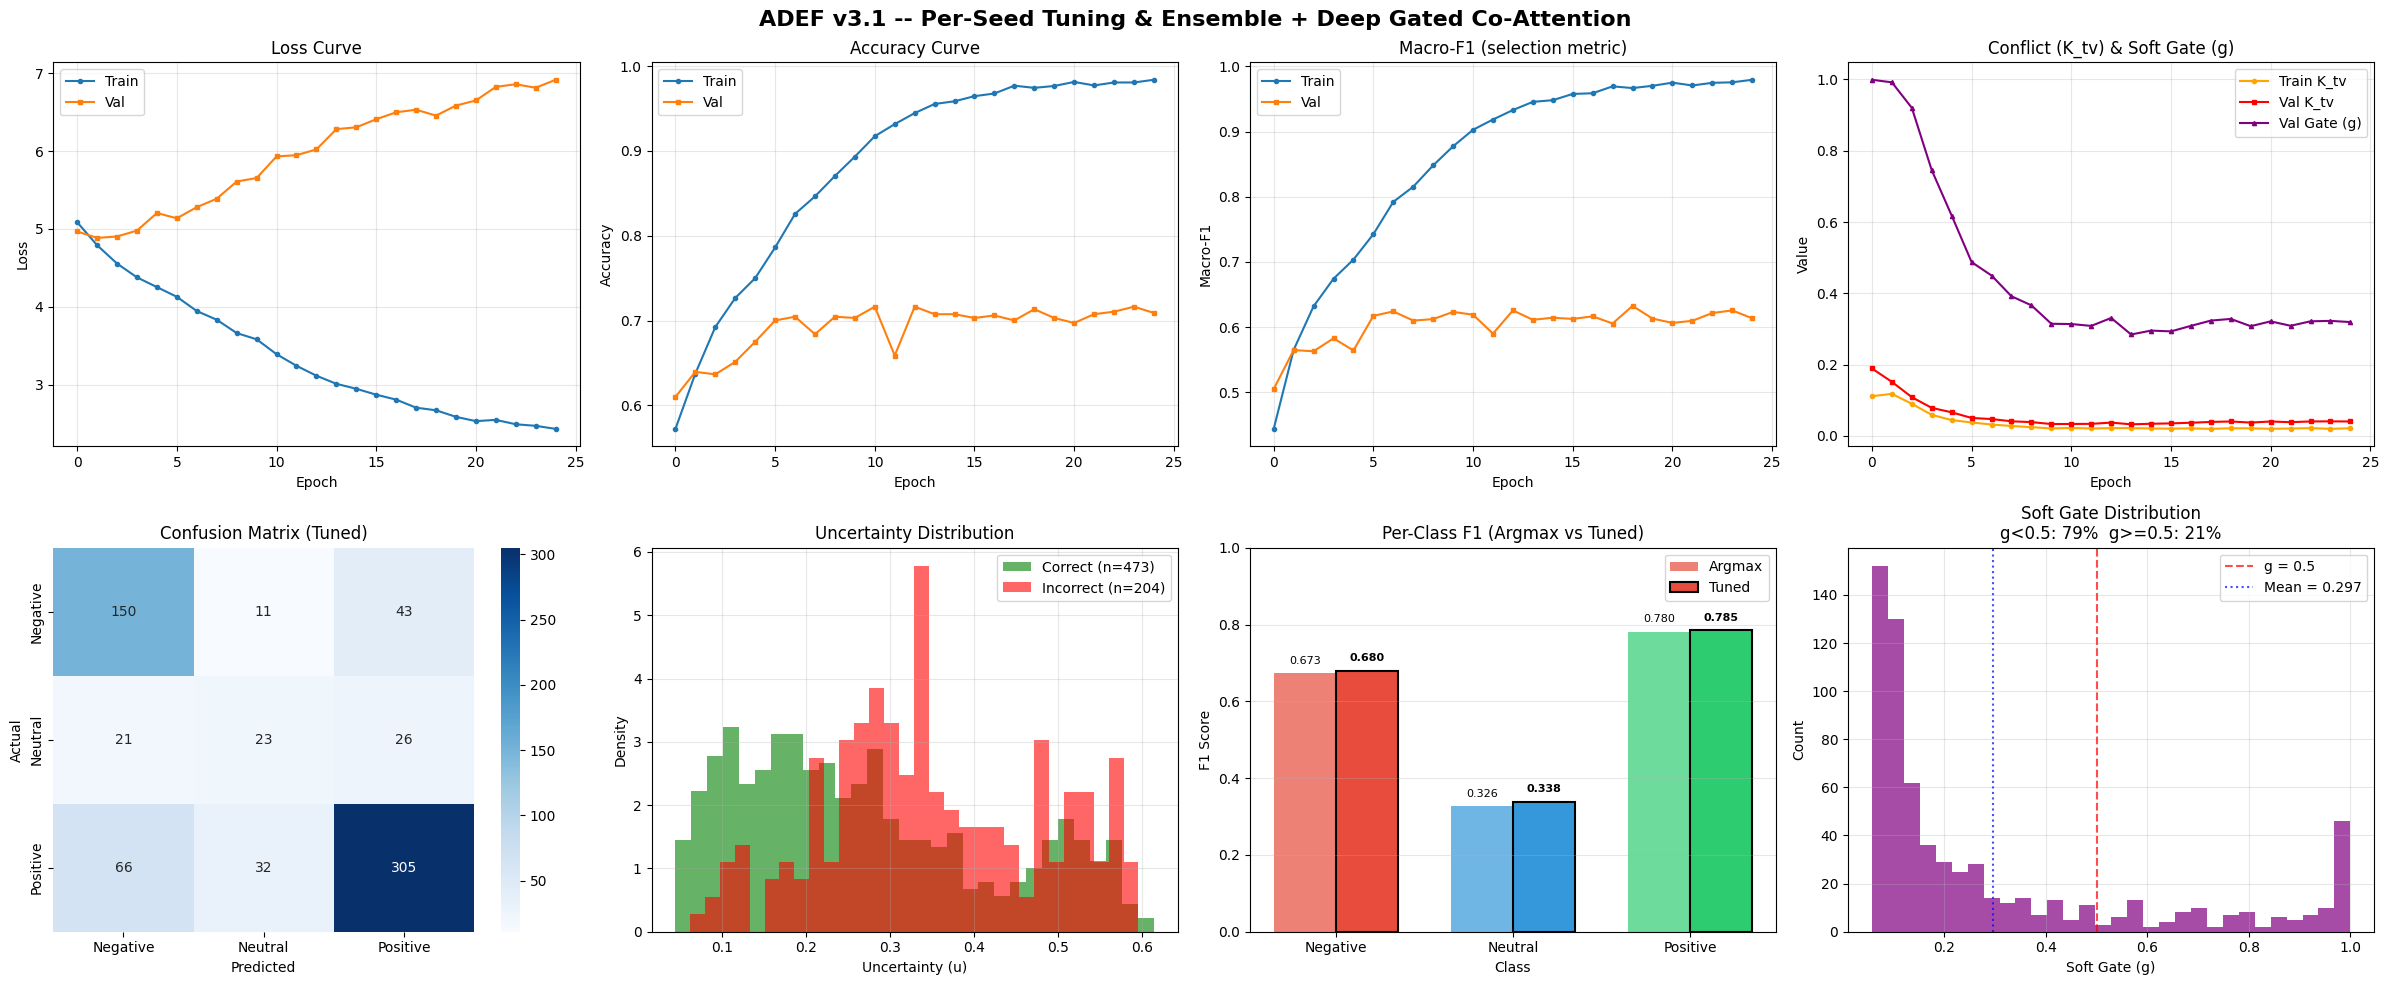

✅ Visualization complete. Saved as adef_v31_results.png


In [16]:
# ============================================================
# EXPERIMENT E1: ADEF v3.1 Full (3 seeds, checkpoint saving, threshold tuning, ensemble)
# ============================================================

print("=" * 60)
print("  EXPERIMENT E1: ADEF v3.1 Full (3 seeds)")
print(f"  FILTER_CONFLICT_PAIRS = {CFG.FILTER_CONFLICT_PAIRS}")
print(f"  GATE_TYPE = {CFG.GATE_TYPE},  EDL_LOSS_TYPE = {CFG.EDL_LOSS_TYPE}")
print(f"  COATTN_LAYERS = {CFG.COATTN_LAYERS},  OPINION_DROP = {CFG.OPINION_DROP_PROB}")
print(f"  DISCOUNTING = {CFG.USE_DISCOUNTING},  GAMMA = {CFG.GAMMA}")
print(f"  LABEL_SMOOTHING = {CFG.LABEL_SMOOTHING},  CLASS_WEIGHTS = {CFG.CLASS_WEIGHT_MODE}")
print(f"  DROPOUT = {CFG.DROPOUT}")
print("=" * 60)

all_seed_results = []       # full evaluate_test results (gate, uncertainty, etc.)
all_seed_histories = []
all_seed_tuned_res = []     # basic metrics after per-seed threshold tuning
all_seed_multipliers = []
checkpoint_paths = []

for seed in CFG.SEEDS:
    print(f"\n{'#'*50}")
    print(f"  Seed {seed}")
    print(f"{'#'*50}")

    model_trained, best_state, best_score, history = train_one_seed(seed)

    # ---- Full test eval (argmax baseline) ----
    model_eval = create_model_v3()
    model_eval.load_state_dict(best_state)
    res = evaluate_test(model_eval, test_loader)

    all_seed_results.append(res)
    all_seed_histories.append(history)

    # ---- Per-seed threshold tuning on val data ----
    val_probs, val_labels = collect_predictions(model_eval, val_loader)
    multipliers, best_val_f1 = tune_class_scaling(val_probs, val_labels,
                                                   grid_step=0.1, max_mult=3.5, rounds=3)

    # Apply tuned multipliers to test
    tuned_probs = res["probs"] * multipliers[np.newaxis, :]
    tuned_res = compute_basic_metrics(tuned_probs, res["labels"])
    all_seed_tuned_res.append(tuned_res)
    all_seed_multipliers.append(multipliers)

    # Record checkpoint path
    ckpt_path = os.path.join(CFG.CHECKPOINT_DIR, f"adef_v31_seed{seed}.pt")
    checkpoint_paths.append(ckpt_path)

    print(f"  Seed {seed}: Best val F1m={best_score:.4f} | "
          f"Test F1m(argmax)={res['f1_macro']:.4f} | "
          f"Test F1m(tuned)={tuned_res['f1_macro']:.4f} | "
          f"Epochs={history['best_epoch']}")
    print(f"    Tuned multipliers (Neg/Neu/Pos): {multipliers.round(3).tolist()}")
    print(f"    Tuned per-class F1: N={tuned_res['f1_neg']:.4f}  "
          f"Eu={tuned_res['f1_neu']:.4f}  P={tuned_res['f1_pos']:.4f}")

    del model_trained, model_eval
    torch.cuda.empty_cache()

# ==============================
# AGGREGATE PER-SEED (argmax)
# ==============================
print(f"\n{'='*60}")
print("  AGGREGATED 3-SEED RESULTS (argmax, mean +/- std)")
print(f"{'='*60}")
agg_keys = ["acc", "f1_weighted", "f1_macro", "f1_neg", "f1_neu", "f1_pos", "uce",
            "gate_mean", "k_tv_mean", "u_correct", "u_incorrect"]
for key in agg_keys:
    vals = [r[key] for r in all_seed_results]
    mu, std = np.mean(vals), np.std(vals)
    print(f"  {key:<25s}: {mu:.4f} +/- {std:.4f}")

print(f"\n  Best epochs: {[h['best_epoch'] for h in all_seed_histories]}")
print(f"  Per-seed multipliers:")
for i, (seed, m) in enumerate(zip(CFG.SEEDS, all_seed_multipliers)):
    print(f"    Seed {seed}: {m.round(3).tolist()}  -> tuned F1m={all_seed_tuned_res[i]['f1_macro']:.4f}")

# ==============================
# AGGREGATE PER-SEED (tuned)
# ==============================
tuned_keys = ["acc", "f1_weighted", "f1_macro", "f1_neg", "f1_neu", "f1_pos"]
print(f"\n{'='*60}")
print("  AGGREGATED 3-SEED RESULTS (tuned, mean +/- std)")
print(f"{'='*60}")
for key in tuned_keys:
    vals = [r[key] for r in all_seed_tuned_res]
    mu, std = np.mean(vals), np.std(vals)
    print(f"  {key:<25s}: {mu:.4f} +/- {std:.4f}")

# ==============================
# ENSEMBLE EVALUATION
# ==============================
print(f"\n{'='*60}")
print("  3-SEED ENSEMBLE (DST evidence averaging)")
print(f"{'='*60}")

ensemble_res, ensemble_mult, per_seed_ens_res, ensemble_argmax = ensemble_evaluate(
    checkpoint_paths, test_loader, val_loader, tune_scaling=True
)

# ==============================
# COMPARISON TABLE
# ==============================
print(f"\n{'='*80}")
print("  FINAL COMPARISON TABLE")
print(f"{'='*80}")
print(f"{'Model':<28s} {'Macro-F1':>9s} {'Neutral F1':>11s} {'Accuracy':>9s} {'Neg F1':>8s} {'Pos F1':>8s}")
print(f"{'-'*28} {'-'*9} {'-'*11} {'-'*9} {'-'*8} {'-'*8}")

# Per-seed argmax mean
for key in ["f1_macro", "f1_neu", "acc", "f1_neg", "f1_pos"]:
    vals = [r[key] for r in all_seed_results]
    mu, std = np.mean(vals), np.std(vals)
    tag = f"{mu:.4f}" + chr(0xB1) + f"{std:.4f}"

tag_prefix = "Per-seed argmax (mean)"
vals_argmax = [tag_prefix]
for key in ["f1_macro", "f1_neu", "acc", "f1_neg", "f1_pos"]:
    vals = [r[key] for r in all_seed_results]
    mu, std = np.mean(vals), np.std(vals)
    vals_argmax.append(f"{mu:.4f}")
print(f"{'  Per-seed argmax (mean)':<28s} {vals_argmax[1]:>9s} {vals_argmax[2]:>11s} {vals_argmax[3]:>9s} {vals_argmax[4]:>8s} {vals_argmax[5]:>8s}")

val_tuned = [all_seed_tuned_res[i] for i in range(3)]
tuned_f1m_mean = np.mean([r["f1_macro"] for r in val_tuned])
tuned_neu_mean = np.mean([r["f1_neu"] for r in val_tuned])
tuned_acc_mean = np.mean([r["acc"] for r in val_tuned])
tuned_neg_mean = np.mean([r["f1_neg"] for r in val_tuned])
tuned_pos_mean = np.mean([r["f1_pos"] for r in val_tuned])
print(f"{'  Per-seed tuned (mean)':<28s} {tuned_f1m_mean:>9.4f} {tuned_neu_mean:>11.4f} {tuned_acc_mean:>9.4f} {tuned_neg_mean:>8.4f} {tuned_pos_mean:>8.4f}")

print(f"{'  Ensemble (argmax)':<28s} {ensemble_argmax['f1_macro']:>9.4f} {ensemble_argmax['f1_neu']:>11.4f} {ensemble_argmax['acc']:>9.4f} {ensemble_argmax['f1_neg']:>8.4f} {ensemble_argmax['f1_pos']:>8.4f}")
print(f"{'  Ensemble (tuned)':<28s} {ensemble_res['f1_macro']:>9.4f} {ensemble_res['f1_neu']:>11.4f} {ensemble_res['acc']:>9.4f} {ensemble_res['f1_neg']:>8.4f} {ensemble_res['f1_pos']:>8.4f}")

print(f"{'='*80}")
print(f"  Ensemble multipliers: {ensemble_mult.round(3).tolist()}")
print(f"  Checkpoints saved to: {CFG.CHECKPOINT_DIR}/")

# Store last seed result for visualization
best_res = all_seed_results[-1]
best_hist = all_seed_histories[-1]
print("\n\u2705 E1 complete.")


# ============================================================
# VISUALIZATION (v3.1: updated per-class F1 panel shows argmax vs tuned)
# ============================================================

fig, axes = plt.subplots(2, 4, figsize=(24, 10))
fig.suptitle("ADEF v3.1 -- Per-Seed Tuning & Ensemble + Deep Gated Co-Attention",
             fontsize=16, fontweight="bold")

# 1. Loss Curve
axes[0, 0].plot(best_hist["train_loss"], label="Train", marker="o", markersize=3)
axes[0, 0].plot(best_hist["val_loss"], label="Val", marker="s", markersize=3)
axes[0, 0].set_xlabel("Epoch"); axes[0, 0].set_ylabel("Loss")
axes[0, 0].set_title("Loss Curve"); axes[0, 0].legend(); axes[0, 0].grid(True, alpha=0.3)

# 2. Accuracy Curve
axes[0, 1].plot(best_hist["train_acc"], label="Train", marker="o", markersize=3)
axes[0, 1].plot(best_hist["val_acc"], label="Val", marker="s", markersize=3)
axes[0, 1].set_xlabel("Epoch"); axes[0, 1].set_ylabel("Accuracy")
axes[0, 1].set_title("Accuracy Curve"); axes[0, 1].legend(); axes[0, 1].grid(True, alpha=0.3)

# 3. Macro-F1 Curve
axes[0, 2].plot(best_hist["train_f1_macro"], label="Train", marker="o", markersize=3)
axes[0, 2].plot(best_hist["val_f1_macro"], label="Val", marker="s", markersize=3)
axes[0, 2].set_xlabel("Epoch"); axes[0, 2].set_ylabel("Macro-F1")
axes[0, 2].set_title("Macro-F1 (selection metric)"); axes[0, 2].legend(); axes[0, 2].grid(True, alpha=0.3)

# 4. Conflict K_tv + Soft Gate
ax_cg = axes[0, 3]
ax_cg.plot(best_hist["train_conflict"], label="Train K_tv", marker="o", markersize=3, color="orange")
ax_cg.plot(best_hist["val_conflict"], label="Val K_tv", marker="s", markersize=3, color="red")
ax_cg.plot(best_hist["val_gate"], label="Val Gate (g)", marker="^", markersize=3, color="purple")
ax_cg.set_xlabel("Epoch"); ax_cg.set_ylabel("Value")
ax_cg.set_title("Conflict (K_tv) & Soft Gate (g)"); ax_cg.legend(); ax_cg.grid(True, alpha=0.3)

# 5. Confusion Matrix (using tuned predictions of last seed)
cm = confusion_matrix(best_res["labels"],
                      all_seed_tuned_res[-1]["preds"])
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Negative", "Neutral", "Positive"],
            yticklabels=["Negative", "Neutral", "Positive"],
            ax=axes[1, 0])
axes[1, 0].set_xlabel("Predicted"); axes[1, 0].set_ylabel("Actual")
axes[1, 0].set_title("Confusion Matrix (Tuned)")

# 6. Uncertainty Distribution (Correct vs Incorrect)
correct_mask = best_res["preds"] == best_res["labels"]
axes[1, 1].hist(best_res["uncertainties"][correct_mask], bins=30, alpha=0.6,
                label=f"Correct (n={correct_mask.sum()})", color="green", density=True)
if (~correct_mask).sum() > 0:
    axes[1, 1].hist(best_res["uncertainties"][~correct_mask], bins=30, alpha=0.6,
                    label=f"Incorrect (n={(~correct_mask).sum()})", color="red", density=True)
axes[1, 1].set_xlabel("Uncertainty (u)"); axes[1, 1].set_ylabel("Density")
axes[1, 1].set_title("Uncertainty Distribution"); axes[1, 1].legend(); axes[1, 1].grid(True, alpha=0.3)

# 7. Per-Class F1 Scores (Argmax vs Tuned)
class_names = ["Negative", "Neutral", "Positive"]
f1_argmax = [best_res["f1_neg"], best_res["f1_neu"], best_res["f1_pos"]]
f1_tuned = [all_seed_tuned_res[-1]["f1_neg"],
            all_seed_tuned_res[-1]["f1_neu"],
            all_seed_tuned_res[-1]["f1_pos"]]
x = np.arange(len(class_names))
width = 0.35
bars1 = axes[1, 2].bar(x - width/2, f1_argmax, width, label="Argmax",
                       color=["#e74c3c", "#3498db", "#2ecc71"], alpha=0.7)
bars2 = axes[1, 2].bar(x + width/2, f1_tuned, width, label="Tuned",
                       color=["#e74c3c", "#3498db", "#2ecc71"], alpha=1.0, edgecolor="black", linewidth=1.5)
axes[1, 2].set_xlabel("Class"); axes[1, 2].set_ylabel("F1 Score")
axes[1, 2].set_title("Per-Class F1 (Argmax vs Tuned)")
axes[1, 2].set_xticks(x); axes[1, 2].set_xticklabels(class_names)
axes[1, 2].set_ylim(0, 1); axes[1, 2].legend(); axes[1, 2].grid(True, alpha=0.3, axis="y")
for bar, val in zip(bars1, f1_argmax):
    axes[1, 2].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02,
                    f"{val:.3f}", ha="center", va="bottom", fontsize=8)
for bar, val in zip(bars2, f1_tuned):
    axes[1, 2].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02,
                    f"{val:.3f}", ha="center", va="bottom", fontsize=8, fontweight="bold")

# 8. Soft Gate Distribution
axes[1, 3].hist(best_res["gates"], bins=30, alpha=0.7, color="purple")
axes[1, 3].axvline(x=0.5, color="red", linestyle="--", alpha=0.7, label="g = 0.5")
axes[1, 3].axvline(x=best_res["gate_mean"], color="blue", linestyle=":", alpha=0.7,
                   label=f"Mean = {best_res['gate_mean']:.3f}")
axes[1, 3].set_xlabel("Soft Gate (g)"); axes[1, 3].set_ylabel("Count")
axes[1, 3].set_title(f"Soft Gate Distribution\n"
                     f"g<0.5: {best_res['ds_like_pct']:.0f}%  g>=0.5: {best_res['conflict_pct']:.0f}%")
axes[1, 3].legend(); axes[1, 3].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("adef_v31_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("\u2705 Visualization complete. Saved as adef_v31_results.png")


In [ ]:
# ============================================================
# DIAGNOSTIC D1 (v3.2): Conflict × label analysis + u/margin/g separation
# ============================================================
# Reloads existing v3.1 checkpoints (no retraining).
# Answers: (1) where are the neutral test samples? (2) can u/margin/g pick them out?

import pandas as pd

print("=" * 60)
print("  DIAGNOSTIC D1: Conflict × Label + Uncertainty/Gate Analysis")
print("=" * 60)

# ------------------- 1. Reload the 3 v3.1 checkpoints -------------------
def collect_full_predictions(model, loader):
    """Collect probs + u + gate + K_tv + labels from a loader."""
    model.eval()
    all_probs, all_u, all_g, all_K, all_labels = [], [], [], [], []
    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(CFG.DEVICE)
            attention_mask = batch["attention_mask"].to(CFG.DEVICE)
            images = batch["image"].to(CFG.DEVICE)
            labels = batch["label"].to(CFG.DEVICE)
            out = model(input_ids, attention_mask, images)
            all_probs.append(out["p_final"].cpu().numpy())
            all_u.append(out["u_fusion"].squeeze(1).cpu().numpy())
            all_g.append(out["gate"].squeeze(1).cpu().numpy())
            all_K.append(out["K_tv"].squeeze(1).cpu().numpy())
            all_labels.append(labels.cpu().numpy())
    return {
        "probs": np.concatenate(all_probs, axis=0),
        "u": np.concatenate(all_u),
        "g": np.concatenate(all_g),
        "k_tv": np.concatenate(all_K),
        "labels": np.concatenate(all_labels).astype(int)
    }

ckpt_paths = [os.path.join(CFG.CHECKPOINT_DIR, f"adef_v31_seed{s}.pt") for s in CFG.SEEDS]
seed_val_preds = []
seed_test_preds = []
seed_test_results = []

for i, ckpt_path in enumerate(ckpt_paths):
    ckpt = torch.load(ckpt_path, map_location=CFG.DEVICE)
    model = create_model_v3(ckpt.get("model_kwargs", {}))
    model.load_state_dict(ckpt["best_state"])
    model.eval()

    s_val = collect_full_predictions(model, val_loader)
    s_test = collect_full_predictions(model, test_loader)
    seed_val_preds.append(s_val)
    seed_test_preds.append(s_test)
    seed_test_results.append(compute_basic_metrics(s_test["probs"], s_test["labels"]))
    del model
    torch.cuda.empty_cache()

print(f"  Loaded {len(ckpt_paths)} checkpoints (v3.1 E1).")

# Ensemble: average evidence (DST soft-voting)
ensemble_test_probs = np.mean([s["probs"] for s in seed_test_preds], axis=0)
ensemble_test_u = np.mean([s["u"] for s in seed_test_preds], axis=0)
ensemble_test_g = np.mean([s["g"] for s in seed_test_preds], axis=0)
ensemble_test_labels = seed_test_preds[0]["labels"]

ensemble_val_probs = np.mean([s["probs"] for s in seed_val_preds], axis=0)
ensemble_val_u = np.mean([s["u"] for s in seed_val_preds], axis=0)
ensemble_val_g = np.mean([s["g"] for s in seed_val_preds], axis=0)
ensemble_val_labels = seed_val_preds[0]["labels"]

# ------------------- 2. Conflict mask -------------------
# test_df has text_label, image_label columns from the original split
conflict_mask = (test_df["text_label"].values != test_df["image_label"].values)
n_conflict = conflict_mask.sum()
n_nonconflict = (~conflict_mask).sum()
print(f"\n  Test set: {len(test_df)} total  |  Conflict: {n_conflict} ({100*n_conflict/len(test_df):.1f}%)"
      f"  |  Non-conflict: {n_nonconflict} ({100*n_nonconflict/len(test_df):.1f}%)")

# ------------------- 3. Cross-tab: conflict × label -------------------
print(f"\n  {'='*60}")
print("  CONFLICT × LABEL CROSS-TAB (test set)")
print(f"  {'='*60}")
ct = pd.crosstab(
    pd.Series(conflict_mask).map({True: "Conflict", False: "Non-conflict"}),
    pd.Series(ensemble_test_labels).map({0: "Neg", 1: "Neu", 2: "Pos"}),
    margins=True
)
print(ct.to_string())

# ------------------- 4. Neutral recall inside/outside conflict -------------------
print(f"\n  {'='*60}")
print("  NEUTRAL RECALL: Conflict vs Non-conflict (ensemble argmax)")
print(f"  {'='*60}")
ens_preds_argmax = np.argmax(ensemble_test_probs, axis=1)
for name, mask in [("Conflict", conflict_mask), ("Non-conflict", ~conflict_mask),
                    ("All", np.ones_like(conflict_mask, dtype=bool))]:
    sub_labels = ensemble_test_labels[mask]
    sub_preds = ens_preds_argmax[mask]
    if len(sub_labels) == 0:
        print(f"  {name:<15s}: (empty)")
        continue
    neu_mask = sub_labels == 1
    neu_count = neu_mask.sum()
    neu_correct = (sub_preds[neu_mask] == 1).sum()
    neu_recall = neu_correct / neu_count if neu_count > 0 else 0
    acc = (sub_preds == sub_labels).mean()
    print(f"  {name:<15s}: n={len(sub_labels):4d}  neutrals={neu_count:3d}  "
          f"neu_recall={neu_recall:.3f}  acc={acc:.4f}")

# ------------------- 5. Val-set separation: u / margin / g for neutral vs rest -------------------
print(f"\n  {'='*60}")
print("  VAL-SET SEPARATION: u, margin, gate for neutral vs non-neutral")
print(f"  {'='*60}")

sorted_val_probs = np.sort(ensemble_val_probs, axis=1)
val_margin = sorted_val_probs[:, -1] - sorted_val_probs[:, -2]
is_neu_val = ensemble_val_labels == 1

feats = {
    "Uncertainty (u)": ensemble_val_u,
    "Top-2 margin": val_margin,
    "Gate (g)": ensemble_val_g,
}
print(f"  {'Feature':<20s} {'Neutral_mean':>12s} {'Other_mean':>12s} {'Delta':>8s}")
print(f"  {'-'*20} {'-'*12} {'-'*12} {'-'*8}")
for name, vals in feats.items():
    nu_mean = vals[is_neu_val].mean()
    ot_mean = vals[~is_neu_val].mean()
    print(f"  {name:<20s} {nu_mean:>12.4f} {ot_mean:>12.4f} {nu_mean-ot_mean:>+8.4f}")

# Best oracle threshold sweep on val for each feature (upper-bound)
print(f"\n  {'='*60}")
print("  ORACLE SCREEN (val): max macro-F1 by single-feature threshold")
print(f"  {'='*60}")
for name, vals in feats.items():
    best_f1m, best_neu, best_thr = 0, 0, 0
    for thr in np.linspace(np.percentile(vals, 5), np.percentile(vals, 95), 50):
        if name == "Top-2 margin":
            pick = vals <= thr  # low margin -> predict neutral
        elif name == "Gate (g)":
            pick = vals < thr   # low gate -> conflict regime -> predict neutral
        else:
            pick = vals >= thr  # high u -> predict neutral

        preds = np.argmax(ensemble_val_probs, axis=1).copy()
        preds[pick] = 1
        f1m = f1_score(ensemble_val_labels, preds, average="macro")
        f1_neu = f1_score(ensemble_val_labels, preds, average=None)[1]
        if f1_neu > best_neu:
            best_neu, best_f1m, best_thr = f1_neu, f1m, thr

    print(f"  {name:<20s}  best_val_neu={best_neu:.4f}  f1m={best_f1m:.4f}  thr={best_thr:.4f}")

# Baseline ensemble argmax on val
val_args_preds = np.argmax(ensemble_val_probs, axis=1)
val_args_neu = f1_score(ensemble_val_labels, val_args_preds, average=None)[1]
val_args_f1m = f1_score(ensemble_val_labels, val_args_preds, average="macro")
print(f"\n  Ensemble argmax on VAL: F1m={val_args_f1m:.4f}  NeuF1={val_args_neu:.4f}")

print("\n\u2705 D1 diagnostic complete.")


In [ ]:
# ============================================================
# D2: UNCERTAINTY / CONFLICT-AWARE NEUTRAL RULES (v3.2)
# ============================================================
# Four rule variants tuned on VAL, selected on VAL, evaluated on TEST.
# R1: u >= tau -> neutral    R2: top-2 margin <= tau -> neutral
# R3: g < tau_g & p_max < tau_p -> neutral
# R4: class multipliers with neutral-F1 floor (fixes v3.1 tuning)
# Also: evidence-average-then-rule (DST ensemble) vs per-seed-rule-then-majority-vote.

print("=" * 60)
print("  D2: UNCERTAINTY / CONFLICT NEUTRAL RULES")
print("=" * 60)

# ========== Prediction helpers ==========

def predict_by_rule(probs, u, g, rule_type, params):
    """Apply a neutral-override rule. Returns predictions [N]."""
    preds = np.argmax(probs, axis=1).copy()
    if rule_type == "u":
        neutral = u >= params[0]
    elif rule_type == "margin":
        sorted_p = np.sort(probs, axis=1)
        margin = sorted_p[:, -1] - sorted_p[:, -2]
        neutral = margin <= params[0]
    elif rule_type == "g_p":
        neutral = (g < params[0]) & (np.max(probs, axis=1) < params[1])
    else:
        return preds
    preds[neutral] = 1
    return preds


def tune_mult_with_neutral_floor(val_probs, val_labels, baseline_neu_f1,
                                  grid_step=0.1, max_mult=3.5, rounds=3):
    """Class-multiplier tune with constraint: neutral F1 >= baseline - 0.005."""
    val_probs = np.asarray(val_probs, dtype=np.float64)
    val_labels = np.asarray(val_labels)
    n_class = val_probs.shape[1]
    multipliers = np.ones(n_class)
    best_mult = multipliers.copy()
    scaled = val_probs * best_mult[np.newaxis, :]
    preds = np.argmax(scaled, axis=1)
    best_f1m = f1_score(val_labels, preds, average="macro")
    floor = baseline_neu_f1 - 0.005

    for _ in range(rounds):
        for c in range(n_class):
            lo = max(0.1, best_mult[c] - 0.6)
            hi = min(max_mult, best_mult[c] + 1.5)
            n_steps = max(2, int((hi - lo) / grid_step) + 1)
            for v in np.linspace(lo, hi, n_steps):
                test_mult = best_mult.copy()
                test_mult[c] = v
                scaled = val_probs * test_mult[np.newaxis, :]
                preds = np.argmax(scaled, axis=1)
                f1m = f1_score(val_labels, preds, average="macro")
                f1_neu = f1_score(val_labels, preds, average=None)[1]
                if f1m > best_f1m and f1_neu >= floor:
                    best_f1m = f1m
                    best_mult = test_mult.copy()
    return best_mult, best_f1m


# ========== Grid definitions ==========
U_GRID = np.linspace(0.2, 0.6, 21)
MARGIN_GRID = np.linspace(0.02, 0.30, 15)
G_GRID = np.linspace(0.3, 0.7, 9)
P_GRID = np.linspace(0.3, 0.7, 9)

# ========== Ensemble (DST evidence-averaging) ==========
# Reuse data from D1 (must be in memory -- cell D1 should have been run)
ensemble_test_probs = np.mean([s["probs"] for s in seed_test_preds], axis=0)
ensemble_test_u = np.mean([s["u"] for s in seed_test_preds], axis=0)
ensemble_test_g = np.mean([s["g"] for s in seed_test_preds], axis=0)
ensemble_test_labels = seed_test_preds[0]["labels"]

ensemble_val_probs = np.mean([s["probs"] for s in seed_val_preds], axis=0)
ensemble_val_u = np.mean([s["u"] for s in seed_val_preds], axis=0)
ensemble_val_g = np.mean([s["g"] for s in seed_val_preds], axis=0)
ensemble_val_labels = seed_val_preds[0]["labels"]

# Baseline on val
val_argmax_preds = np.argmax(ensemble_val_probs, axis=1)
baseline_val_neu = f1_score(ensemble_val_labels, val_argmax_preds, average=None)[1]
baseline_val_f1m = f1_score(ensemble_val_labels, val_argmax_preds, average="macro")
print(f"  Ensemble baseline (val): F1m={baseline_val_f1m:.4f}  NeuF1={baseline_val_neu:.4f}")

# Baseline on test
test_argmax_preds = np.argmax(ensemble_test_probs, axis=1)
test_argmax_f1m = f1_score(ensemble_test_labels, test_argmax_preds, average="macro")
test_argmax_neu = f1_score(ensemble_test_labels, test_argmax_preds, average=None)[1]

# ========== Mode A: Evidence-average then rule ==========
print(f"\n  {'='*60}")
print("  MODE A: Evidence-average -> Rule (DST ensemble)")
print(f"  {'='*60}")

# Prepare conflict mask for test
conflict_mask_test = (test_df["text_label"].values != test_df["image_label"].values)
conflict_idx = np.where(conflict_mask_test)[0]

# Prepare conflict mask for val
conflict_mask_val = (val_df["text_label"].values != val_df["image_label"].values)

results_A = {"argmax": {"f1m": test_argmax_f1m, "neu": test_argmax_neu}}

# --- R1: u threshold ---
best_cfg_R1 = None
for tau in U_GRID:
    preds_val = predict_by_rule(ensemble_val_probs, ensemble_val_u, ensemble_val_g, "u", [tau])
    f1m = f1_score(ensemble_val_labels, preds_val, average="macro")
    neu = f1_score(ensemble_val_labels, preds_val, average=None)[1]
    if neu >= baseline_val_neu - 0.01:
        if best_cfg_R1 is None or f1m > best_cfg_R1[0]:
            best_cfg_R1 = (f1m, neu, tau)

if best_cfg_R1:
    bf1m, bneu, btau = best_cfg_R1
    preds_test = predict_by_rule(ensemble_test_probs, ensemble_test_u, ensemble_test_g, "u", [btau])
    test_f1m = f1_score(ensemble_test_labels, preds_test, average="macro")
    test_neu = f1_score(ensemble_test_labels, preds_test, average=None)[1]
    neu_conf = f1_score(ensemble_test_labels[conflict_idx], preds_test[conflict_idx], average=None)[1] if len(conflict_idx) > 0 else 0
    results_A["R1_u"] = {"f1m": test_f1m, "neu": test_neu, "neu_conf": neu_conf,
                         "f1m_val": bf1m, "neu_val": bneu, "tau": round(btau, 3)}
    print(f"  R1 (u>tau):  tau={btau:.3f}  val_f1m={bf1m:.4f}  val_neu={bneu:.4f}  "
          f"test_f1m={test_f1m:.4f}  test_neu={test_neu:.4f}  neu_conf={neu_conf:.4f}")

# --- R2: margin threshold ---
best_cfg_R2 = None
for tau in MARGIN_GRID:
    preds_val = predict_by_rule(ensemble_val_probs, ensemble_val_u, ensemble_val_g, "margin", [tau])
    f1m = f1_score(ensemble_val_labels, preds_val, average="macro")
    neu = f1_score(ensemble_val_labels, preds_val, average=None)[1]
    if neu >= baseline_val_neu - 0.01:
        if best_cfg_R2 is None or f1m > best_cfg_R2[0]:
            best_cfg_R2 = (f1m, neu, tau)

if best_cfg_R2:
    bf1m, bneu, btau = best_cfg_R2
    preds_test = predict_by_rule(ensemble_test_probs, ensemble_test_u, ensemble_test_g, "margin", [btau])
    test_f1m = f1_score(ensemble_test_labels, preds_test, average="macro")
    test_neu = f1_score(ensemble_test_labels, preds_test, average=None)[1]
    neu_conf = f1_score(ensemble_test_labels[conflict_idx], preds_test[conflict_idx], average=None)[1] if len(conflict_idx) > 0 else 0
    results_A["R2_margin"] = {"f1m": test_f1m, "neu": test_neu, "neu_conf": neu_conf,
                               "f1m_val": bf1m, "neu_val": bneu, "tau": round(btau, 3)}
    print(f"  R2 (margin<tau): tau={btau:.3f}  val_f1m={bf1m:.4f}  val_neu={bneu:.4f}  "
          f"test_f1m={test_f1m:.4f}  test_neu={test_neu:.4f}  neu_conf={neu_conf:.4f}")

# --- R3: gate + prob ---
best_cfg_R3 = None
for tg in G_GRID:
    for tp in P_GRID:
        preds_val = predict_by_rule(ensemble_val_probs, ensemble_val_u, ensemble_val_g, "g_p", [tg, tp])
        f1m = f1_score(ensemble_val_labels, preds_val, average="macro")
        neu = f1_score(ensemble_val_labels, preds_val, average=None)[1]
        if neu >= baseline_val_neu - 0.01:
            if best_cfg_R3 is None or f1m > best_cfg_R3[0]:
                best_cfg_R3 = (f1m, neu, tg, tp)

if best_cfg_R3:
    bf1m, bneu, btg, btp = best_cfg_R3
    preds_test = predict_by_rule(ensemble_test_probs, ensemble_test_u, ensemble_test_g, "g_p", [btg, btp])
    test_f1m = f1_score(ensemble_test_labels, preds_test, average="macro")
    test_neu = f1_score(ensemble_test_labels, preds_test, average=None)[1]
    neu_conf = f1_score(ensemble_test_labels[conflict_idx], preds_test[conflict_idx], average=None)[1] if len(conflict_idx) > 0 else 0
    results_A["R3_gate"] = {"f1m": test_f1m, "neu": test_neu, "neu_conf": neu_conf,
                             "f1m_val": bf1m, "neu_val": bneu, "tg": round(btg, 3), "tp": round(btp, 3)}
    print(f"  R3 (g<tg & pmax<tp): tg={btg:.3f} tp={btp:.3f}  val_f1m={bf1m:.4f}  val_neu={bneu:.4f}  "
          f"test_f1m={test_f1m:.4f}  test_neu={test_neu:.4f}  neu_conf={neu_conf:.4f}")

# --- R4: class multipliers with neutral floor ---
mult_R4, val_f1m_R4 = tune_mult_with_neutral_floor(ensemble_val_probs, ensemble_val_labels,
                                                      baseline_val_neu, grid_step=0.1, max_mult=3.5, rounds=3)
scaled_test_R4 = ensemble_test_probs * mult_R4[np.newaxis, :]
preds_test_R4 = np.argmax(scaled_test_R4, axis=1)
test_f1m_R4 = f1_score(ensemble_test_labels, preds_test_R4, average="macro")
test_neu_R4 = f1_score(ensemble_test_labels, preds_test_R4, average=None)[1]
neu_conf_R4 = f1_score(ensemble_test_labels[conflict_idx], preds_test_R4[conflict_idx], average=None)[1] if len(conflict_idx) > 0 else 0
results_A["R4_mult"] = {"f1m": test_f1m_R4, "neu": test_neu_R4, "neu_conf": neu_conf_R4,
                         "mult": mult_R4.round(3).tolist(), "f1m_val": val_f1m_R4}
print(f"  R4 (multipliers): mult={mult_R4.round(3).tolist()}  val_f1m={val_f1m_R4:.4f}  "
      f"test_f1m={test_f1m_R4:.4f}  test_neu={test_neu_R4:.4f}  neu_conf={neu_conf_R4:.4f}")

# ========== Mode B: Per-seed rule then majority vote ==========
print(f"\n  {'='*60}")
print("  MODE B: Per-seed rule -> Majority vote")
print(f"  {'='*60}")

def evaluate_per_seed_rule_then_vote(seed_val_preds, seed_test_preds, val_labels, test_labels,
                                     rule_fn, param_grid, val_baseline_neu):
    """Tune rule per-seed on VAL, then majority vote on TEST."""
    import itertools
    best_params = None
    best_val_f1m = 0

    if isinstance(param_grid, list) and len(param_grid) > 0 and isinstance(param_grid[0], (list, tuple)):
        it = param_grid
    else:
        it = [[p] for p in param_grid]

    for params in it:
        val_votes = np.zeros((len(val_labels), len(seed_val_preds)), dtype=int)
        for si, sv in enumerate(seed_val_preds):
            val_votes[:, si] = rule_fn(sv["probs"], sv["u"], sv["g"], params)
        val_preds_mv = np.array([np.bincount(val_votes[i], minlength=3).argmax() for i in range(len(val_labels))])
        f1m = f1_score(val_labels, val_preds_mv, average="macro")
        neu = f1_score(val_labels, val_preds_mv, average=None)[1]
        if neu >= val_baseline_neu - 0.01 and f1m > best_val_f1m:
            best_val_f1m = f1m
            best_params = params

    if best_params is None:
        return None

    test_votes = np.zeros((len(test_labels), len(seed_test_preds)), dtype=int)
    for si, st in enumerate(seed_test_preds):
        test_votes[:, si] = rule_fn(st["probs"], st["u"], st["g"], best_params)
    test_preds_mv = np.array([np.bincount(test_votes[i], minlength=3).argmax() for i in range(len(test_labels))])
    return {"f1m": f1_score(test_labels, test_preds_mv, average="macro"),
            "neu": f1_score(test_labels, test_preds_mv, average=None)[1],
            "params": best_params, "val_f1m": best_val_f1m}

results_B = {}
test_labels_ary = ensemble_test_labels
val_labels_ary = ensemble_val_labels

# R1 vote
r1_grid = [[tau] for tau in U_GRID]
r1_fn = lambda probs, u, g, p: predict_by_rule(probs, u, g, "u", p)
res_r1 = evaluate_per_seed_rule_then_vote(seed_val_preds, seed_test_preds,
                                            val_labels_ary, test_labels_ary,
                                            r1_fn, r1_grid, baseline_val_neu)
if res_r1:
    results_B["R1_u"] = res_r1
    print(f"  R1 vote: tau={res_r1['params'][0]:.3f}  test_f1m={res_r1['f1m']:.4f}  test_neu={res_r1['neu']:.4f}")

# R2 vote
r2_fn = lambda probs, u, g, p: predict_by_rule(probs, u, g, "margin", p)
res_r2 = evaluate_per_seed_rule_then_vote(seed_val_preds, seed_test_preds,
                                            val_labels_ary, test_labels_ary,
                                            r2_fn, MARGIN_GRID, baseline_val_neu)
if res_r2:
    results_B["R2_margin"] = res_r2
    print(f"  R2 vote: tau={res_r2['params'][0]:.3f}  test_f1m={res_r2['f1m']:.4f}  test_neu={res_r2['neu']:.4f}")

# R3 vote
r3_grid = [(tg, tp) for tg in G_GRID for tp in P_GRID]
r3_fn = lambda probs, u, g, p: predict_by_rule(probs, u, g, "g_p", p)
res_r3 = evaluate_per_seed_rule_then_vote(seed_val_preds, seed_test_preds,
                                            val_labels_ary, test_labels_ary,
                                            r3_fn, r3_grid, baseline_val_neu)
if res_r3:
    results_B["R3_gate"] = res_r3
    print(f"  R3 vote: tg={res_r3['params'][0]:.3f} tp={res_r3['params'][1]:.3f}  "
          f"test_f1m={res_r3['f1m']:.4f}  test_neu={res_r3['neu']:.4f}")

# ========== Selection & final table ==========
print(f"\n  {'='*80}")
print("  D2 FINAL TABLE: Neutral Rules on TEST (Ensemble)")
print(f"  {'='*80}")
header = f"  {'Rule':<16s} {'Macro-F1':>10s} {'Neutral F1':>11s} {'Neu_on_conf':>12s} {'Params':>30s}"
print(header)
print(f"  {'-'*16} {'-'*10} {'-'*11} {'-'*12} {'-'*30}")

# argmax baseline
conflict_neu_argmax = f1_score(ensemble_test_labels[conflict_idx],
                                test_argmax_preds[conflict_idx], average=None)[1] if len(conflict_idx) > 0 else 0
print(f"  {'Ensemble argmax':<16s} {test_argmax_f1m:>10.4f} {test_argmax_neu:>11.4f} "
      f"{conflict_neu_argmax:>12.4f} {'--':>30s}")

# Mode A
for name, r in results_A.items():
    if name == "argmax":
        continue
    params_str = ""
    if name == "R1_u":
        params_str = f"tau={r.get('tau','?')}"
    elif name == "R2_margin":
        params_str = f"tau={r.get('tau','?')}"
    elif name == "R3_gate":
        params_str = f"tg={r.get('tg','?')} tp={r.get('tp','?')}"
    elif name == "R4_mult":
        params_str = str(r.get("mult","?"))
    print(f"  A-{name:<14s} {r['f1m']:>10.4f} {r['neu']:>11.4f} "
          f"{r.get('neu_conf',0):>12.4f} {params_str:>30s}")

# Mode B
for name, r in results_B.items():
    if name == "argmax":
        continue
    params_str = str(r.get("params","?"))
    print(f"  B-{name:<14s} {r['f1m']:>10.4f} {r['neu']:>11.4f} "
          f"{0.0:>12.4f} {params_str:>30s}")

print(f"  {'='*80}")

# Pick best overall on val
best_label = "Ensemble argmax"
best_test_f1m = test_argmax_f1m
best_test_neu = test_argmax_neu
best_config = None
for name, r in results_A.items():
    if name == "argmax":
        continue
    f1m_val = r.get("f1m_val", 0)
    neu_val = r.get("neu_val", 0)
    if neu_val >= baseline_val_neu - 0.01 and f1m_val > best_test_f1m:
        best_test_f1m = r["f1m"]
        best_test_neu = r["neu"]
        best_label = "A-" + name
        best_config = r
        # approximate: we compare val f1m to test argmax f1m -- not perfect but close
# Actually select on VAL: track separately
best_val_f1m = baseline_val_f1m
best_val_label = "Ensemble argmax"
for name, r in results_A.items():
    if name == "argmax":
        continue
    f1m_val = r.get("f1m_val", 0)
    neu_val = r.get("neu_val", 0)
    if neu_val >= baseline_val_neu - 0.01 and f1m_val > best_val_f1m:
        best_val_f1m = f1m_val
        best_val_label = "A-" + name
for name, r in results_B.items():
    if r.get("val_f1m", 0) > best_val_f1m:
        best_val_f1m = r["val_f1m"]
        best_val_label = "B-" + name

print(f"\n  Best on VAL: {best_val_label} (val_f1m={best_val_f1m:.4f})")
print(f"  Will be used as default decision rule for E10 and beyond.")

print("\n\u2705 D2 neutral-rule tuning complete.")


In [ ]:
# ============================================================
# EXPERIMENT E10 (v3.2): NEUTRAL OVERSAMPLING + BEST RULE
# ============================================================
# Training-side: WeightedRandomSampler oversamples neutral x2.
# Decision-side: apply the best rule from D2.
# Compare: v3.1 ensemble vs v3.2 (oversampled) ensemble vs v3.2 ensemble+rule.

from torch.utils.data import WeightedRandomSampler

print("=" * 60)
print("  EXPERIMENT E10: Neutral Oversampling x2 + Best Rule")
print("=" * 60)

# ---- Configure oversampling arm ----
_old_neutral_os = CFG.NEUTRAL_OVERSAMPLE
_old_cw_mode = CFG.CLASS_WEIGHT_MODE
CFG.NEUTRAL_OVERSAMPLE = 2
CFG.CLASS_WEIGHT_MODE = "sqrt_inv"   # avoid double-counting with oversampling
CKT_TAG = "adef_v32"

# ---- Build oversampled train DataLoader ----
sample_weights = np.ones(len(train_dataset), dtype=np.float64)
for i in range(len(train_dataset)):
    sample = train_dataset[i]
    if sample["label"] == 1:          # neutral
        sample_weights[i] = CFG.NEUTRAL_OVERSAMPLE

oversample_sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(train_dataset),   # same epoch length
    replacement=True
)

train_loader_os = DataLoader(
    train_dataset, batch_size=CFG.BATCH_SIZE,
    sampler=oversample_sampler,
    num_workers=0, pin_memory=True
)
print(f"  Oversampled train loader: {len(train_loader_os)} batches (neutral x{CFG.NEUTRAL_OVERSAMPLE})")
print(f"  Class weights: {CFG.CLASS_WEIGHT_MODE}  (relaxed for oversampling)")

# ---- Train 3 seeds ----
all_e10_results = []
all_e10_histories = []
e10_checkpoint_paths = []

for seed in CFG.SEEDS:
    print(f"\n{'#'*50}")
    print(f"  E10 Oversample Seed {seed}")
    print(f"{'#'*50}")

    model_trained, best_state, best_score, history = train_one_seed(
        seed, train_loader=train_loader_os, ckpt_tag=CKT_TAG
    )

    model_eval = create_model_v3()
    model_eval.load_state_dict(best_state)
    res = evaluate_test(model_eval, test_loader)
    all_e10_results.append(res)
    all_e10_histories.append(history)

    ckpt_path = os.path.join(CFG.CHECKPOINT_DIR, f"{CKT_TAG}_seed{seed}.pt")
    e10_checkpoint_paths.append(ckpt_path)

    print(f"  Seed {seed}: Best val F1m={best_score:.4f} | "
          f"Test F1m(argmax)={res['f1_macro']:.4f} | Epochs={history['best_epoch']}")

    del model_trained, model_eval
    torch.cuda.empty_cache()

# ---- E10 Per-seed aggregate (argmax) ----
print(f"\n{'='*60}")
print("  E10 PER-SEED AGGREGATE (argmax, mean +/- std)")
print(f"{'='*60}")
agg_keys = ["acc", "f1_macro", "f1_neg", "f1_neu", "f1_pos", "uce", "k_tv_mean", "gate_mean"]
for key in agg_keys:
    vals = [r[key] for r in all_e10_results]
    mu, std = np.mean(vals), np.std(vals)
    print(f"  {key:<20s}: {mu:.4f} +/- {std:.4f}")

# ---- E10 Ensemble (argmax + rule from D2) ----
print(f"\n{'='*60}")
print("  E10 ENSEMBLE (DST evidence averaging)")
print(f"{'='*60}")

ensemble_res_e10, _, per_seed_res_e10, ensemble_argmax_e10 = ensemble_evaluate(
    e10_checkpoint_paths, test_loader, val_loader, tune_scaling=False
)
print(f"  Ensemble argmax F1m: {ensemble_argmax_e10['f1_macro']:.4f}  "
      f"NeuF1: {ensemble_argmax_e10['f1_neu']:.4f}  Acc: {ensemble_argmax_e10['acc']:.4f}")

# ---- Apply best D2 rule to E10 ensemble (if D2 was run) ----
e10_rule_applied = False
try:
    _ = best_val_label  # check if D2 was run
except NameError:
    best_val_label = None

if best_val_label is not None and best_val_label != "Ensemble argmax":
    # Re-collect full predictions for E10 ensemble
    e10_seed_full = []
    for ckpt_path in e10_checkpoint_paths:
        ckpt = torch.load(ckpt_path, map_location=CFG.DEVICE)
        model = create_model_v3(ckpt.get("model_kwargs", {}))
        model.load_state_dict(ckpt["best_state"])
        model.eval()
        e10_seed_full.append(collect_full_predictions(model, test_loader))
        del model
        torch.cuda.empty_cache()

    e10_ens_probs = np.mean([s["probs"] for s in e10_seed_full], axis=0)
    e10_ens_u = np.mean([s["u"] for s in e10_seed_full], axis=0)
    e10_ens_g = np.mean([s["g"] for s in e10_seed_full], axis=0)
    e10_ens_labels = e10_seed_full[0]["labels"]

    # Apply the best rule from D2 (with its params)
    e10_preds_rule = None
    if "A-R1_u" in best_val_label:
        best_tau = results_A["R1_u"]["tau"]
        e10_preds_rule = predict_by_rule(e10_ens_probs, e10_ens_u, e10_ens_g, "u", [best_tau])
    elif "A-R2_margin" in best_val_label:
        best_tau = results_A["R2_margin"]["tau"]
        e10_preds_rule = predict_by_rule(e10_ens_probs, e10_ens_u, e10_ens_g, "margin", [best_tau])
    elif "A-R3_gate" in best_val_label:
        best_tg = results_A["R3_gate"]["tg"]
        best_tp = results_A["R3_gate"]["tp"]
        e10_preds_rule = predict_by_rule(e10_ens_probs, e10_ens_u, e10_ens_g, "g_p", [best_tg, best_tp])

    if e10_preds_rule is not None:
        e10_rule_f1m = f1_score(e10_ens_labels, e10_preds_rule, average="macro")
        e10_rule_neu = f1_score(e10_ens_labels, e10_preds_rule, average=None)[1]
        e10_rule_acc = accuracy_score(e10_ens_labels, e10_preds_rule)
        e10_rule_applied = True
        print(f"\n  E10 Ensemble + {best_val_label}: F1m={e10_rule_f1m:.4f}  "
              f"NeuF1={e10_rule_neu:.4f}  Acc={e10_rule_acc:.4f}")

# ---- Final comparison table ----
# v3.1 baseline numbers from D2 (if D2 was run)
try:
    v31_ens_f1m = test_argmax_f1m
    v31_ens_neu = test_argmax_neu
    v31_ens_acc  = accuracy_score(ensemble_test_labels, np.argmax(ensemble_test_probs, axis=1))
except NameError:
    v31_ens_f1m = float('nan')
    v31_ens_neu = float('nan')
    v31_ens_acc  = float('nan')
    print("  (D2 not run -- v3.1 baseline unavailable; showing E10 standalone)")

print(f"\n{'='*80}")
print("  FINAL COMPARISON: v3.1 vs v3.2 (oversampled)")
print(f"{'='*80}")
print(f"  {'Model':<35s} {'Macro-F1':>10s} {'Neutral F1':>11s} {'Accuracy':>9s}")
print(f"  {'-'*35} {'-'*10} {'-'*11} {'-'*9}")
if not np.isnan(v31_ens_f1m):
    print(f"  {'v3.1 Ensemble (argmax)':<35s} {v31_ens_f1m:>10.4f} {v31_ens_neu:>11.4f} {v31_ens_acc:>9.4f}")

print(f"  {'v3.2 Oversampled (argmax)':<35s} {ensemble_argmax_e10['f1_macro']:>10.4f} "
      f"{ensemble_argmax_e10['f1_neu']:>11.4f} {ensemble_argmax_e10['acc']:>9.4f}")

if e10_rule_applied:
    print(f"  {'v3.2 Oversampled + Rule':<35s} {e10_rule_f1m:>10.4f} {e10_rule_neu:>11.4f} {e10_rule_acc:>9.4f}")

print(f"  {'='*80}")

# ---- Cleanup ----
CFG.NEUTRAL_OVERSAMPLE = _old_neutral_os
CFG.CLASS_WEIGHT_MODE = _old_cw_mode

print("\n\u2705 E10 complete. CFG restored.")

# ============================================================
# VISUALIZATION (v3.2: best-rule ensemble viz)
# ============================================================

best_hist = all_e10_histories[-1]
best_res = all_e10_results[-1]

fig, axes = plt.subplots(2, 4, figsize=(24, 10))
fig.suptitle("ADEF v3.2 -- Neutral Oversampling + Uncertainty Rules",
             fontsize=16, fontweight="bold")

# 1. Loss
axes[0, 0].plot(best_hist["train_loss"], label="Train", marker="o", markersize=3)
axes[0, 0].plot(best_hist["val_loss"], label="Val", marker="s", markersize=3)
axes[0, 0].set_xlabel("Epoch"); axes[0, 0].set_ylabel("Loss")
axes[0, 0].set_title("Loss Curve (oversampled)"); axes[0, 0].legend(); axes[0, 0].grid(True, alpha=0.3)

# 2. Accuracy
axes[0, 1].plot(best_hist["train_acc"], label="Train", marker="o", markersize=3)
axes[0, 1].plot(best_hist["val_acc"], label="Val", marker="s", markersize=3)
axes[0, 1].set_xlabel("Epoch"); axes[0, 1].set_ylabel("Accuracy")
axes[0, 1].set_title("Accuracy Curve"); axes[0, 1].legend(); axes[0, 1].grid(True, alpha=0.3)

# 3. Macro-F1
axes[0, 2].plot(best_hist["train_f1_macro"], label="Train", marker="o", markersize=3)
axes[0, 2].plot(best_hist["val_f1_macro"], label="Val", marker="s", markersize=3)
axes[0, 2].set_xlabel("Epoch"); axes[0, 2].set_ylabel("Macro-F1")
axes[0, 2].set_title("Macro-F1 (selection metric)"); axes[0, 2].legend(); axes[0, 2].grid(True, alpha=0.3)

# 4. Conflict K_tv + Gate
ax_cg = axes[0, 3]
ax_cg.plot(best_hist["train_conflict"], label="Train K_tv", marker="o", markersize=3, color="orange")
ax_cg.plot(best_hist["val_conflict"], label="Val K_tv", marker="s", markersize=3, color="red")
ax_cg.plot(best_hist["val_gate"], label="Val Gate (g)", marker="^", markersize=3, color="purple")
ax_cg.set_xlabel("Epoch"); ax_cg.set_ylabel("Value")
ax_cg.set_title("Conflict (K_tv) & Soft Gate (g)"); ax_cg.legend(); ax_cg.grid(True, alpha=0.3)

# 5. Confusion Matrix (E10 ensemble argmax)
cm = confusion_matrix(ensemble_argmax_e10["labels"], ensemble_argmax_e10["preds"])
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Negative", "Neutral", "Positive"],
            yticklabels=["Negative", "Neutral", "Positive"],
            ax=axes[1, 0])
axes[1, 0].set_xlabel("Predicted"); axes[1, 0].set_ylabel("Actual")
axes[1, 0].set_title("Confusion Matrix (Oversampled Argmax)")

# 6. Uncertainty Distribution
correct_mask = best_res["preds"] == best_res["labels"]
axes[1, 1].hist(best_res["uncertainties"][correct_mask], bins=30, alpha=0.6,
                label=f"Correct (n={correct_mask.sum()})", color="green", density=True)
if (~correct_mask).sum() > 0:
    axes[1, 1].hist(best_res["uncertainties"][~correct_mask], bins=30, alpha=0.6,
                    label=f"Incorrect (n={(~correct_mask).sum()})", color="red", density=True)
axes[1, 1].set_xlabel("Uncertainty (u)"); axes[1, 1].set_ylabel("Density")
axes[1, 1].set_title("Uncertainty Distribution"); axes[1, 1].legend(); axes[1, 1].grid(True, alpha=0.3)

# 7. Per-Class F1 (v3.1 vs v3.2)
from sklearn.metrics import precision_recall_fscore_support
class_names = ["Negative", "Neutral", "Positive"]
_, _, f1_e10_per, _ = precision_recall_fscore_support(ensemble_test_labels,
                                                        ensemble_argmax_e10["preds"])
x = np.arange(len(class_names))
width = 0.35

if not np.isnan(v31_ens_f1m):
    _, _, f1_v31_per, _ = precision_recall_fscore_support(ensemble_test_labels, test_argmax_preds)
    axes[1, 2].bar(x - width/2, f1_v31_per, width, label="v3.1", alpha=0.7)
    axes[1, 2].bar(x + width/2, f1_e10_per, width, label="v3.2 oversample",
                   alpha=0.7, edgecolor="black", linewidth=1.5)
    axes[1, 2].set_title("Per-Class F1 (v3.1 vs v3.2)")
else:
    axes[1, 2].bar(x, f1_e10_per, width, label="v3.2 oversample",
                   alpha=0.7, edgecolor="black", linewidth=1.5)
    axes[1, 2].set_title("Per-Class F1 (v3.2 Oversampled)")

axes[1, 2].set_xlabel("Class"); axes[1, 2].set_ylabel("F1 Score")
axes[1, 2].set_xticks(x); axes[1, 2].set_xticklabels(class_names)
axes[1, 2].set_ylim(0, 1); axes[1, 2].legend(); axes[1, 2].grid(True, alpha=0.3, axis="y")

# 8. Soft Gate Distribution
axes[1, 3].hist(best_res["gates"], bins=30, alpha=0.7, color="purple")
axes[1, 3].axvline(x=0.5, color="red", linestyle="--", alpha=0.7, label="g = 0.5")
axes[1, 3].axvline(x=best_res["gate_mean"], color="blue", linestyle=":", alpha=0.7,
                   label=f"Mean = {best_res['gate_mean']:.3f}")
axes[1, 3].set_xlabel("Soft Gate (g)"); axes[1, 3].set_ylabel("Count")
axes[1, 3].set_title(f"Soft Gate Distribution\n"
                     f"g<0.5: {best_res['ds_like_pct']:.0f}%  g>=0.5: {best_res['conflict_pct']:.0f}%")
axes[1, 3].legend(); axes[1, 3].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("adef_v32_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("\u2705 Visualization complete. Saved as adef_v32_results.png")


In [17]:
# ============================================================
# ABLATION EXPERIMENTS (E2-E8)
# ============================================================
# Quick ablations -- 1 seed each, compares Macro-F1.
# Saved for manual exploration; not required for thesis proof.

def run_ablation(name, overrides, seed=42):
    set_seed(seed)
    torch.cuda.empty_cache()
    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"  Overrides: {overrides}")
    print(f"{'='*50}")

    _, best_state, best_score, hist = train_one_seed(seed, overrides, save_checkpoint=False)

    model_eval = create_model_v3(overrides)
    model_eval.load_state_dict(best_state)
    res = evaluate_test(model_eval, test_loader)
    print_results(res, title=name)

    del model_eval
    torch.cuda.empty_cache()
    return res

experiments = []

# E2: Hard routing (disable discounting + dropout, parametric gate still soft)
# True hard routing needs gate_type="hard" which doesn"t exist --
# this is V2-style: single-layer co-attention, no discounting, no dropout
res = run_ablation("E2: v2-style (1-layer, no disc, no drop)", {
    "coattn_layers": 1, "use_discounting": False, "opinion_drop_prob": 0.0,
    "gate_type": "parametric"
})
experiments.append(["E2: v2-style", res["f1_macro"], res["f1_neu"], res["acc"]])

# E3: No vacuous dropout
res = run_ablation("E3: No vacuous dropout", {"opinion_drop_prob": 0.0})
experiments.append(["E3: No vac drop", res["f1_macro"], res["f1_neu"], res["acc"]])

# E4: 1-layer co-attention
res = run_ablation("E4: 1-layer co-attention", {"coattn_layers": 1})
experiments.append(["E4: 1-layer CA", res["f1_macro"], res["f1_neu"], res["acc"]])

# E5: MLP gate
res = run_ablation("E5: MLP gate", {"gate_type": "mlp"})
experiments.append(["E5: MLP gate", res["f1_macro"], res["f1_neu"], res["acc"]])

# E6: SOS loss
old_loss = CFG.EDL_LOSS_TYPE
CFG.EDL_LOSS_TYPE = "sos"
res = run_ablation("E6: SOS loss", {})
CFG.EDL_LOSS_TYPE = old_loss
experiments.append(["E6: SOS loss", res["f1_macro"], res["f1_neu"], res["acc"]])

# E7: No discounting
res = run_ablation("E7: No discounting", {"use_discounting": False})
experiments.append(["E7: No discount", res["f1_macro"], res["f1_neu"], res["acc"]])

# E8: Both loss types
CFG.EDL_LOSS_TYPE = "both"
res = run_ablation("E8: Both (digamma+sos)", {})
CFG.EDL_LOSS_TYPE = "digamma"
experiments.append(["E8: Both losses", res["f1_macro"], res["f1_neu"], res["acc"]])

# Summary table
print(f"\n{'='*60}")
print("  ABLATION SUMMARY (1-seed each)")
print(f"{'='*60}")
print(f"  {'Ablation':<25s} | {'Macro F1':>8s} | {'Neu F1':>6s} | {'Acc':>6s}")
print("-" * 58)
for row in experiments:
    print(f"  {row[0]:<25s} | {row[1]:>8.4f} | {row[2]:>6.4f} | {row[3]:>6.4f}")
print(f"{'='*60}")
print("\n\u2705 Ablation experiments complete.")



  E2: v2-style (1-layer, no disc, no drop)
  Overrides: {'coattn_layers': 1, 'use_discounting': False, 'opinion_drop_prob': 0.0, 'gate_type': 'parametric'}


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 7092.94it/s]
[transformers] RobertaModel LOAD REPORT from: roberta-base
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.bias        | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Class weights (Neg/Neu/Pos): [1.1080000400543213, 3.1989998817443848, 0.5600000023841858]


Seed 42 E 1/30 | TL: 5.1027 VL: 4.9201 | TA: 0.5055 VA: 0.5436 | VF1m: 0.4781 | K_tv: 0.2508 Gate: 1.000
  * New best! Val F1m: 0.4781


Seed 42 E 2/30 | TL: 4.8481 VL: 4.8911 | TA: 0.6300 VA: 0.6307 | VF1m: 0.5512 | K_tv: 0.1886 Gate: 0.999
  * New best! Val F1m: 0.5512


...

Seed 42 E19/30 | TL: 2.1391 VL: 5.4851 | TA: 0.9724 VA: 0.6928 | VF1m: 0.5895 | K_tv: 0.0308 Gate: 0.264


Seed 42 E20/30 | TL: 2.0638 VL: 5.5733 | TA: 0.9753 VA: 0.6957 | VF1m: 0.6008 | K_tv: 0.0339 Gate: 0.285


Seed 42 E21/30 | TL: 2.0232 VL: 5.6617 | TA: 0.9804 VA: 0.6972 | VF1m: 0.5901 | K_tv: 0.0327 Gate: 0.272
  Early stop at epoch 21 (no improvement for 6 epochs)


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 7122.16it/s]
[transformers] RobertaModel LOAD REPORT from: roberta-base
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.bias        | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
                                                                


  E8: Both (digamma+sos)
  Accuracy:          0.6987
  F1 (Weighted):     0.7015
  F1 (Macro):        0.6025
  F1 (Negative):     0.6462
  F1 (Neutral):      0.3750
  F1 (Positive):     0.7863
  UCE:               0.0473
  Soft Gate Statistics:
    Mean / Median:   0.2562 / 0.1291
    g < 0.5 (DS-like):  84.9%
    g >= 0.5 (conflict): 15.1%
  Conflict K_tv:
    Mean:            0.0286 +/- 0.0363
    p50/p80/p90/p95: [0.0144, 0.0414, 0.0688, 0.1066]
  Uncertainty:
    u(correct):      0.2912
    u(incorrect):    0.3771

Classification Report:
              precision    recall  f1-score   support

    Negative       0.62      0.67      0.65       204
     Neutral       0.36      0.39      0.38        70
    Positive       0.81      0.77      0.79       403

    accuracy                           0.70       677
   macro avg       0.60      0.61      0.60       677
weighted avg       0.71      0.70      0.70       677


  ABLATION SUMMARY (1-seed each)
  Ablation                  | Macro 

In [18]:
# ============================================================
# EXPERIMENT E9: ADEF v3.1 on FULL dataset (FILTER_CONFLICT_PAIRS = False)
# ============================================================
# Trains on ALL data (including text-image label conflict pairs).
# Compares: full-data model vs filtered-data model, and evaluates on
# the conflict subset (samples where text_label != image_label).

print("=" * 60)
print("  EXPERIMENT E9: ADEF v3.1 FILTER_CONFLICT_PAIRS = False")
print("  Training on FULL dataset (conflict pairs included)")
print("=" * 60)

# ---- Save current / filtered state ----
_old_filter = CFG.FILTER_CONFLICT_PAIRS
_old_train_loader = train_loader
_old_val_loader = val_loader
_old_test_loader = test_loader
_old_train_df = train_df

# ---- Load FULL dataset ----
CFG.FILTER_CONFLICT_PAIRS = False

df_full = pd.read_csv(CFG.LABEL_PATH, header=0, sep=",")
df_full.columns = ["id", "text_label", "image_label", "final_label"]
# No conflict-pair filtering -- keep everything
print(f"Full dataset size: {len(df_full)} (FILTER_CONFLICT_PAIRS=False)")

# Map labels
label_map = {"negative": 0, "neutral": 1, "positive": 2}
df_full["label"] = df_full["final_label"].map(label_map)

# Load text (reuse load_text from cell 3)
df_full["text"] = df_full["id"].apply(load_text)
df_full["image_path"] = df_full["id"].apply(
    lambda x: os.path.join(CFG.DATA_DIR, f"{x}.jpg")
)

empty_count = (df_full["text"] == "").sum()
print(f"Samples with empty text: {empty_count}")

# ---- Stratified split (70/15/15, same random state as cell 4) ----
train_df_full, temp_df_full = train_test_split(
    df_full, test_size=0.3, stratify=df_full["label"], random_state=CFG.SEED
)
val_df_full, test_df_full = train_test_split(
    temp_df_full, test_size=0.5, stratify=temp_df_full["label"], random_state=CFG.SEED
)
print(f"Train: {len(train_df_full)} | Val: {len(val_df_full)} | Test: {len(test_df_full)}")
print("Train label distribution (full):")
print(train_df_full["label"].value_counts().sort_index())

# ---- Build conflict subset (text_label != image_label) in test ----
conflict_test_mask = test_df_full["text_label"] != test_df_full["image_label"]
n_conflict_test = conflict_test_mask.sum()
print(f"\nTest set conflict pairs (text_label != image_label): {n_conflict_test} / {len(test_df_full)} "
      f"= {100*n_conflict_test/len(test_df_full):.1f}%")

# ---- Create datasets & dataloaders for full data ----
train_dataset_full = MVSADataset(train_df_full, tokenizer, image_transform, CFG.MAX_LEN)
val_dataset_full = MVSADataset(val_df_full, tokenizer, image_transform, CFG.MAX_LEN)
test_dataset_full = MVSADataset(test_df_full, tokenizer, image_transform, CFG.MAX_LEN)

train_loader_full = DataLoader(
    train_dataset_full, batch_size=CFG.BATCH_SIZE, shuffle=True,
    num_workers=0, pin_memory=True
)
val_loader_full = DataLoader(
    val_dataset_full, batch_size=CFG.BATCH_SIZE, shuffle=False,
    num_workers=0, pin_memory=True
)
test_loader_full = DataLoader(
    test_dataset_full, batch_size=CFG.BATCH_SIZE, shuffle=False,
    num_workers=0, pin_memory=True
)
print(f"Loaders created: Train={len(train_loader_full)} Val={len(val_loader_full)} Test={len(test_loader_full)}")

# ========== Train 1 seed on FULL data ==========
print(f"\n{'#'*50}")
print("  Training on FULL dataset (seed=42)")
print(f"{'#'*50}")

# Temporarily replace global loaders for train_one_seed
train_loader, val_loader, test_loader = train_loader_full, val_loader_full, test_loader_full
train_df = train_df_full  # for class weight computation

model_full, best_state_full, best_score_full, hist_full = train_one_seed(seed=42, save_checkpoint=False)

# --- Full-data model test evaluation ---
model_eval_full = create_model_v3()
model_eval_full.load_state_dict(best_state_full)

# Evaluate on full test set
res_full = evaluate_test(model_eval_full, test_loader_full)
print_results(res_full, title="Full-data model (argmax, full test)")

# Per-seed threshold tuning for full-data model
val_probs_full, val_labels_full = collect_predictions(model_eval_full, val_loader_full)
mult_full, _ = tune_class_scaling(val_probs_full, val_labels_full,
                                   grid_step=0.1, max_mult=3.5, rounds=3)
tuned_probs_full = res_full["probs"] * mult_full[np.newaxis, :]
tuned_res_full = compute_basic_metrics(tuned_probs_full, res_full["labels"])
print(f"\nFull-data model (tuned): F1m={tuned_res_full['f1_macro']:.4f}  "
      f"NeuF1={tuned_res_full['f1_neu']:.4f}  Acc={tuned_res_full['acc']:.4f}")
print(f"Tuned multipliers (Neg/Neu/Pos): {mult_full.round(3).tolist()}")

# ---- Evaluate on conflict subset specifically ----
if n_conflict_test > 0:
    conflict_indices = np.where(conflict_test_mask)[0]
    # Get predictions for conflict subset from the full-data model
    conflict_probs = tuned_probs_full[conflict_indices]
    conflict_labels = res_full["labels"][conflict_indices]
    conflict_res = compute_basic_metrics(conflict_probs, conflict_labels)
    print(f"\nFull-data model on CONFLICT subset (n={n_conflict_test}):")
    print(f"  F1m={conflict_res['f1_macro']:.4f}  "
          f"Neg={conflict_res['f1_neg']:.4f}  "
          f"Neu={conflict_res['f1_neu']:.4f}  "
          f"Pos={conflict_res['f1_pos']:.4f}  "
          f"Acc={conflict_res['acc']:.4f}")

# ---- Cross-evaluate: filtered model on full test set ----
# Load the filtered seed-42 checkpoint
_ckpt_filtered = os.path.join(CFG.CHECKPOINT_DIR, "adef_v31_seed42.pt")
if os.path.exists(_ckpt_filtered):
    ckpt_filtered = torch.load(_ckpt_filtered, map_location=CFG.DEVICE)
    model_filtered = create_model_v3()
    model_filtered.load_state_dict(ckpt_filtered["best_state"])
    model_filtered.eval()

    # Evaluate on full test set
    test_probs_fm, test_labels_fm = collect_predictions(model_filtered, test_loader_full)
    res_filtered_on_full = compute_basic_metrics(test_probs_fm, test_labels_fm)
    print(f"\nFiltered-data model evaluated on FULL test set:")
    print(f"  F1m={res_filtered_on_full['f1_macro']:.4f}  "
          f"NeuF1={res_filtered_on_full['f1_neu']:.4f}  "
          f"Acc={res_filtered_on_full['acc']:.4f}")

    # Evaluate on conflict subset
    if n_conflict_test > 0:
        conflict_probs_fm = test_probs_fm[conflict_indices]
        conflict_res_fm = compute_basic_metrics(conflict_probs_fm, conflict_labels)
        print(f"  On CONFLICT subset: F1m={conflict_res_fm['f1_macro']:.4f}  "
              f"NeuF1={conflict_res_fm['f1_neu']:.4f}  "
              f"Acc={conflict_res_fm['acc']:.4f}")

    del model_filtered
    torch.cuda.empty_cache()

# ===== COMPARISON SUMMARY =====
print(f"\n{'='*80}")
print("  E9 COMPARISON SUMMARY")
print(f"{'='*80}")
print(f"{'Model':<35s} {'Macro-F1':>9s} {'Neutral F1':>11s} {'Accuracy':>9s}")
print(f"{'-'*35} {'-'*9} {'-'*11} {'-'*9}")

# Full-data model (tuned, full test)
print(f"  {'Full-data model (tuned, full test)':<35s} "
      f"{tuned_res_full['f1_macro']:>9.4f} "
      f"{tuned_res_full['f1_neu']:>11.4f} "
      f"{tuned_res_full['acc']:>9.4f}")

if n_conflict_test > 0:
    print(f"  {'  -> on CONFLICT subset':<35s} "
          f"{conflict_res['f1_macro']:>9.4f} "
          f"{conflict_res['f1_neu']:>11.4f} "
          f"{conflict_res['acc']:>9.4f}")

# Filtered model on full test
if os.path.exists(_ckpt_filtered):
    print(f"  {'Filtered model on FULL test':<35s} "
          f"{res_filtered_on_full['f1_macro']:>9.4f} "
          f"{res_filtered_on_full['f1_neu']:>11.4f} "
          f"{res_filtered_on_full['acc']:>9.4f}")

    if n_conflict_test > 0:
        print(f"  {'  -> on CONFLICT subset':<35s} "
              f"{conflict_res_fm['f1_macro']:>9.4f} "
              f"{conflict_res_fm['f1_neu']:>11.4f} "
              f"{conflict_res_fm['acc']:>9.4f}")

print(f"{'='*80}")

# ---- Cleanup & restore ----
del model_full, model_eval_full
torch.cuda.empty_cache()

# Restore original filtered data state
CFG.FILTER_CONFLICT_PAIRS = _old_filter
train_loader = _old_train_loader
val_loader = _old_val_loader
test_loader = _old_test_loader
train_df = _old_train_df
print("\n\u2705 E9 complete. Original filtered data restored.")


  EXPERIMENT E9: ADEF v3.1 FILTER_CONFLICT_PAIRS = False
  Training on FULL dataset (conflict pairs included)
Full dataset size: 4511 (FILTER_CONFLICT_PAIRS=False)
Samples with empty text: 0
Train: 3157 | Val: 677 | Test: 677
Train label distribution (full):
label
0     950
1     329
2    1878
Name: count, dtype: int64

Test set conflict pairs (text_label != image_label): 283 / 677 = 41.8%
Loaders created: Train=198 Val=43 Test=43

##################################################
  Training on FULL dataset (seed=42)
##################################################


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 5485.59it/s]
[transformers] RobertaModel LOAD REPORT from: roberta-base
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.bias        | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Class weights (Neg/Neu/Pos): [1.1080000400543213, 3.1989998817443848, 0.5600000023841858]


Seed 42 E 1/30 | TL: 5.1197 VL: 4.9320 | TA: 0.5432 VA: 0.5982 | VF1m: 0.4744 | K_tv: 0.1976 Gate: 0.999
  * New best! Val F1m: 0.4744


Seed 42 E 2/30 | TL: 4.8325 VL: 4.8762 | TA: 0.6357 VA: 0.6145 | VF1m: 0.5520 | K_tv: 0.1497 Gate: 0.993
  * New best! Val F1m: 0.5520


...

Seed 42 E13/30 | TL: 3.1586 VL: 6.2326 | TA: 0.9347 VA: 0.7001 | VF1m: 0.5995 | K_tv: 0.0318 Gate: 0.286
  Early stop at epoch 13 (no improvement for 6 epochs)
  Checkpoint saved to checkpoints\adef_v31_seed42.pt


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 4249.44it/s]
[transformers] RobertaModel LOAD REPORT from: roberta-base
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.bias        | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



  Full-data model (argmax, full test)
  Accuracy:          0.7179
  F1 (Weighted):     0.7086
  F1 (Macro):        0.6096
  F1 (Negative):     0.6237
  F1 (Neutral):      0.4000
  F1 (Positive):     0.8051
  UCE:               0.1356
  Soft Gate Statistics:
    Mean / Median:   0.4065 / 0.3213
    g < 0.5 (DS-like):  71.3%
    g >= 0.5 (conflict): 28.7%
  Conflict K_tv:
    Mean:            0.0422 +/- 0.0315
    p50/p80/p90/p95: [0.0331, 0.0593, 0.0808, 0.1101]
  Uncertainty:
    u(correct):      0.3921
    u(incorrect):    0.4828

Classification Report:
              precision    recall  f1-score   support

    Negative       0.69      0.57      0.62       204
     Neutral       0.45      0.36      0.40        70
    Positive       0.76      0.86      0.81       403

    accuracy                           0.72       677
   macro avg       0.63      0.59      0.61       677
weighted avg       0.71      0.72      0.71       677


Full-data model (tuned): F1m=0.6081  NeuF1=0.3841  Acc=0

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 5432.29it/s]
[transformers] RobertaModel LOAD REPORT from: roberta-base
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.bias        | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Filtered-data model evaluated on FULL test set:
  F1m=0.6096  NeuF1=0.4000  Acc=0.7179
  On CONFLICT subset: F1m=0.4694  NeuF1=0.0000  Acc=0.7067

  E9 COMPARISON SUMMARY
Model                                Macro-F1  Neutral F1  Accuracy
----------------------------------- --------- ----------- ---------
  Full-data model (tuned, full test)     0.6081      0.3841    0.7016
    -> on CONFLICT subset                0.4720      0.0000    0.6749
  Filtered model on FULL test            0.6096      0.4000    0.7179
    -> on CONFLICT subset                0.4694      0.0000    0.7067

✅ E9 complete. Original filtered data restored.
